# Análisis Exploratorio de Datos

## Guia

https://spotintelligence.com/2023/09/15/exploratory-data-analysis-nlp/

## Problema de Investigación

Datos tomados de: https://www.sciencedirect.com/science/article/pii/S2352340925000162

## Categorías y Descripciones

1. **Economic**
- **Descripción**: Costos, beneficios u otras implicaciones financieras.
- **Ejemplo**: Artículos que analizan el impacto económico de las políticas de inmigración.

2. **Capacity and Resources**
- **Descripción**: Disponibilidad de recursos físicos, humanos o financieros, y la capacidad de los sistemas actuales.
- **Ejemplo**: Cobertura sobre la capacidad del sistema de salud durante una pandemia.

3. **Morality**
- **Descripción**: Implicaciones religiosas o éticas.
- **Ejemplo**: Debates sobre las leyes del aborto.

4. **Fairness and Equality**
- **Descripción**: Equilibrio o distribución de derechos, responsabilidades y recursos.
- **Ejemplo**: Discusiones sobre la desigualdad de ingresos y la justicia social.

5. **Legality, Constitutionality, and Jurisprudence**
- **Descripción**: Derechos, libertades y autoridad de individuos, corporaciones y el gobierno.
- **Ejemplo**: Análisis legales sobre nuevas legislaciones que afectan las libertades civiles.

6. **Policy Prescription and Evaluation**
- **Descripción**: Discusión sobre políticas específicas dirigidas a abordar problemas.
- **Ejemplo**: Opiniones sobre estrategias de mitigación del cambio climático.

7. **Crime and Punishment**
- **Descripción**: Efectividad e implicaciones de las leyes y su aplicación.
- **Ejemplo**: Informes sobre los esfuerzos de reforma del sistema de justicia penal.

8. **Security and Defense**
- **Descripción**: Amenazas al bienestar del individuo, la comunidad o la nación.
- **Ejemplo**: Preocupaciones sobre la seguridad nacional relacionadas con el control fronterizo.

9. **Health and Safety**
- **Descripción**: Atención médica, saneamiento y seguridad pública.
- **Ejemplo**: Medidas para combatir la propagación de enfermedades infecciosas.

10. **Quality of Life**
- **Descripción**: Amenazas y oportunidades para la riqueza, felicidad y bienestar del individuo.
- **Ejemplo**: El impacto del desarrollo urbano en el bienestar de los residentes.

11. **Cultural Identity**
- **Descripción**: Tradiciones, costumbres o valores de un grupo social en relación con un tema político.
- **Ejemplo**: Preservación de los idiomas y culturas indígenas.

12. **Public Opinion**
- **Descripción**: Actitudes y opiniones del público en general, incluidas encuestas y demografía.
- **Ejemplo**: Encuestas sobre el apoyo público a las fuentes de energía renovable.

13. **Political**
- **Descripción**: Consideraciones relacionadas con la política y los políticos, incluidas actividades de cabildeo, elecciones e intentos de influir en los votantes.
- **Ejemplo**: Estrategias de campaña electoral y esfuerzos de movilización de votantes.

14. **External Regulation and Reputation**
- **Descripción**: Reputación internacional o política exterior.
- **Ejemplo**: Relaciones diplomáticas y acuerdos internacionales.

15. **Other**
- **Descripción**: Cualquier grupo coherente de marcos no cubierto por las categorías anteriores.
- **Ejemplo**: Marcos únicos o emergentes específicos de problemas contemporáneos.


## Objetivo General

## Objetivos Específicos

## Paso 1: Cargar Librerías

In [1]:
# !python -m spacy download es_core_news_sm

In [2]:
#!python -m spacy download es_dep_news_trf


In [3]:
#!python -m spacy download es_core_news_lg


In [4]:
# !pip install networkx


In [5]:
# !pip install scipy

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import os
import string
import spacy
import math
import networkx as nx

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.util import ngrams
from collections import Counter
from wordcloud import WordCloud
from itertools import combinations
from scipy import stats
from collections import defaultdict


In [7]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\guill\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\guill\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\guill\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

## Paso 2: Cargar Datos

In [8]:
df = pd.read_csv("../data/labels.csv")

In [9]:
# Obtener la ruta actual del notebook
print("Directorio actual:", os.getcwd())

Directorio actual: C:\Users\guill\Documents\GitHub\nlp-media-framing\notebooks


In [10]:
# Ruta de la carpeta que contiene los archivos de texto
folder_path = "../data/articles/"

In [11]:
# Obtener la lista de archivos con extensión .txt en la carpeta
files = [f for f in os.listdir(folder_path) if f.endswith(".txt")]

In [12]:
# Leer el contenido de cada archivo y almacenarlo en una lista
article_data = []
for file in files:
    with open(os.path.join(folder_path, file), "r", encoding="utf-8") as f:
        content = f.read()
        article_data.append(content)

In [13]:
# Crear un DataFrame con una columna "news"
df.insert(1, "news", article_data)

In [14]:
# Mostrar las primeras filas del DataFrame
df.head()

,id,news,frames,tone,principal_frames,economic,capacity_and_resources,morality,fairness_and_equality,legality_constitutionality_and_jurisprudence,policy_prescription_and_evaluation,crime_and_punishment,security_and_defense,health_and_safety,quality_of_life,cultural_identity,public_opinion,political,external_regulation_and_reputation
0,Noticia_1.txt,¿Cuánto tiempo estoy autorizado a permanecer e...,"['external_regulation_and_reputation', 'legali...",neutral,legality_constitutionality_and_jurisprudence,0,0,0,0,1,1,1,0,0,0,0,0,0,1
1,Noticia_2.txt,Colombia y Venezuela instalaron comisión de ve...,"['policy_prescription_and_evaluation', 'politi...",neutral,political,1,0,1,0,0,1,0,0,0,0,0,1,1,1
2,Noticia_7.txt,"Atrasar proceso electoral hasta enero de 2024,...","['political', 'quality_of_life', 'public_opini...",neutral,political,0,0,0,0,0,0,0,0,0,1,0,1,1,0
3,Noticia_8.txt,Avanza SLP en cuanto a transparencia presupues...,"['policy_prescription_and_evaluation', 'public...",neutral,policy_prescription_and_evaluation,0,0,0,0,0,1,0,0,0,0,0,1,0,1
4,Noticia_9.txt,Confía dirigente del PT en mantener el registr...,"['external_regulation_and_reputation', 'qualit...",negative,fairness_and_equality,0,1,0,1,0,1,0,0,0,1,0,1,0,1


In [15]:
df.tail()

,id,news,frames,tone,principal_frames,economic,capacity_and_resources,morality,fairness_and_equality,legality_constitutionality_and_jurisprudence,policy_prescription_and_evaluation,crime_and_punishment,security_and_defense,health_and_safety,quality_of_life,cultural_identity,public_opinion,political,external_regulation_and_reputation
135,Noticia_120.txt,Vacaciones de terror: agencia de viajes poblan...,"['public_opinion', 'political', 'quality_of_li...",neutral,political,0,0,0,0,0,0,0,0,0,1,0,1,1,0
136,Noticia_119.txt,"En SLP, la gasolina más barata se vende por de...","['capacity_and_resources', 'economic', 'politi...",neutral,economic,1,1,0,0,0,0,0,0,0,0,0,1,1,0
137,Noticia_118.txt,Inflación baja a 4.79% en la primera mitad de ...,"['security_and_defense', 'political']",positive,security_and_defense,0,0,0,0,0,0,0,1,0,0,0,0,1,0
138,Noticia_117.txt,Reducción de jornada laboral provocará un desp...,"['security_and_defense', 'morality', 'public_o...",neutral,security_and_defense,0,0,1,0,1,0,0,1,0,1,0,1,1,0
139,Noticia_116.txt,Advierte Ricardo Gallardo más cambios en su ga...,"['policy_prescription_and_evaluation', 'public...",positive,policy_prescription_and_evaluation,0,0,0,1,0,1,0,0,0,0,0,1,1,0


## Paso 1: Estadísticas básicas

In [16]:
def compute_statistics(text):
    word_count = len(text.split())  # Number of words
    char_count = len(text)  # Number of characters
    sentence_count = len(re.split(r'[.!?]', text)) - 1  # Number of sentences
    avg_word_length = sum(len(word) for word in text.split()) / word_count if word_count > 0 else 0  # Average word length
    return pd.Series([word_count, char_count, sentence_count, avg_word_length],
                     index=['word_count', 'character_count', 'sentence_count', 'average_word_length'])

In [17]:
# Apply function to dataset
data_stats = df['news'].apply(compute_statistics)

# Combine with original data
df = pd.concat([df, data_stats], axis=1)

# Display results
df.head()

,id,news,frames,tone,principal_frames,economic,capacity_and_resources,morality,fairness_and_equality,legality_constitutionality_and_jurisprudence,...,health_and_safety,quality_of_life,cultural_identity,public_opinion,political,external_regulation_and_reputation,word_count,character_count,sentence_count,average_word_length
0,Noticia_1.txt,¿Cuánto tiempo estoy autorizado a permanecer e...,"['external_regulation_and_reputation', 'legali...",neutral,legality_constitutionality_and_jurisprudence,0,0,0,0,1,...,0,0,0,0,0,1,512.0,3148.0,25.0,4.976562
1,Noticia_2.txt,Colombia y Venezuela instalaron comisión de ve...,"['policy_prescription_and_evaluation', 'politi...",neutral,political,1,0,1,0,0,...,0,0,0,1,1,1,423.0,2661.0,16.0,5.210402
2,Noticia_7.txt,"Atrasar proceso electoral hasta enero de 2024,...","['political', 'quality_of_life', 'public_opini...",neutral,political,0,0,0,0,0,...,0,1,0,1,1,0,316.0,2023.0,5.0,5.395570
3,Noticia_8.txt,Avanza SLP en cuanto a transparencia presupues...,"['policy_prescription_and_evaluation', 'public...",neutral,policy_prescription_and_evaluation,0,0,0,0,0,...,0,0,0,1,0,1,338.0,1934.0,7.0,4.713018
4,Noticia_9.txt,Confía dirigente del PT en mantener el registr...,"['external_regulation_and_reputation', 'qualit...",negative,fairness_and_equality,0,1,0,1,0,...,0,1,0,1,0,1,323.0,1890.0,4.0,4.848297


### Paso 1.1 Conteo de Palabras

In [18]:
mean_wc = df["word_count"].mean()
median_wc = df["word_count"].median()

# Skewness (bias)
skew_wc = stats.skew(df["word_count"].dropna())

# Kurtosis (peakedness)
kurt_wc = stats.kurtosis(df["word_count"].dropna())

# Print the results
print(f"Media (Mean): {mean_wc:.2f}")
print(f"Mediana (Median): {median_wc}")
print(f"Asimetría (Skewness): {skew_wc:.2f}")
print(f"Curtosis (Kurtosis): {kurt_wc:.2f}")

Media (Mean): 497.46
Mediana (Median): 437.0
Asimetría (Skewness): 2.16
Curtosis (Kurtosis): 5.59


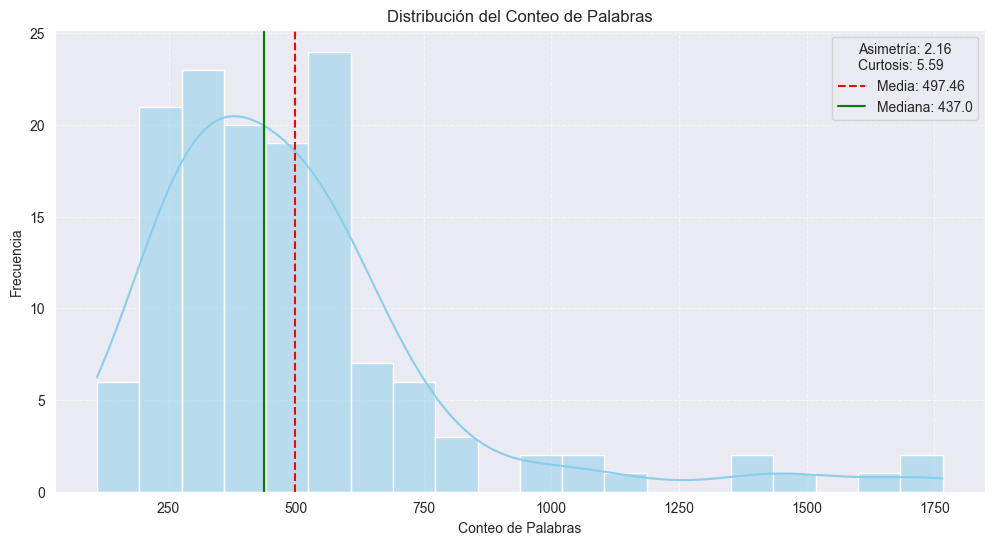

In [19]:
sns.set_style("darkgrid")
plt.figure(figsize=(12, 6))

# Histogram with KDE
sns.histplot(data=df, x="word_count", bins=20, kde=True, color="skyblue")

# Central tendency lines
plt.axvline(mean_wc, color='red', linestyle='--', label=f'Media: {mean_wc:.2f}')
plt.axvline(median_wc, color='green', linestyle='-', label=f'Mediana: {median_wc}')

# Labels and info
plt.title("Distribución del Conteo de Palabras")
plt.xlabel("Conteo de Palabras")
plt.ylabel("Frecuencia")
plt.legend(title=f"Asimetría: {skew_wc:.2f}\nCurtosis: {kurt_wc:.2f}")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### Paso 1.1.1: Interpretación de la Distribución del Conteo de Palabras
La mayoría de los artículos de noticias presentan una concentración de entre 200 y 500 palabras, con una marcada concentración en ese rango. La distribución del conteo de palabras es asimétrica positivamente (asimetría = 2.16), lo que indica la presencia de textos atípicamente largos, algunos con más de 1000 palabras. Además, la curtosis elevada (5.59) revela una distribución leptocúrtica, es decir, con un pico más pronunciado y colas más pesadas en comparación con una distribución normal. La diferencia entre la media (497.46) y la mediana (437.0) refuerza esta asimetría, sugiriendo que unos pocos artículos extensos están elevando el promedio general.


### Paso 1.2 Conteo de caracteres

In [20]:
# Calcular media, mediana, asimetría y curtosis
mean = df["character_count"].mean()
median = df["character_count"].median()
skewness = df["character_count"].skew()
kurtosis = df["character_count"].kurt()

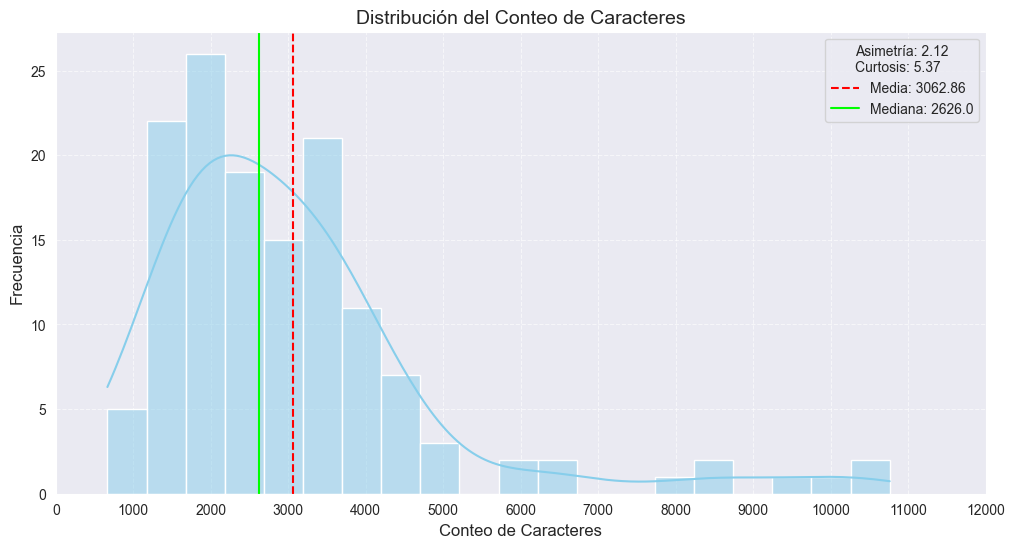

In [21]:
sns.set_style("darkgrid")
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x="character_count", bins=20, kde=True, color="skyblue")

# Central tendency lines
plt.axvline(mean, color='red', linestyle='--', linewidth=1.5, label=f"Media: {mean:.2f}")
plt.axvline(median, color='lime', linestyle='-', linewidth=1.5, label=f"Mediana: {median:.1f}")

# Labels and info
plt.title("Distribución del Conteo de Caracteres", fontsize=14)
plt.xlabel("Conteo de Caracteres", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
ticks = np.arange(0, plt.xlim()[1] + 1000, 1000)
plt.xticks(ticks)
plt.legend(title=f"Asimetría: {skewness:.2f}\nCurtosis: {kurtosis:.2f}")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### Paso 1.2.1: Interpretación de la Distribución del Conteo de Caracteres

La mayoría de los artículos de noticias tienen una extensión que se concentra entre 1500 y 3500 caracteres, lo cual indica una tendencia hacia textos relativamente breves o moderados. Sin embargo, la distribución muestra una asimetría positiva considerable (asimetría = 2.12), lo que revela la presencia de artículos atípicamente extensos, algunos con más de 8000 caracteres.

Además, la curtosis elevada (5.37) indica que la distribución es leptocúrtica, es decir, con un pico más pronunciado y colas más pesadas que una distribución normal. Esto sugiere que, aunque la mayoría de los artículos tienen una longitud moderada, existe una mayor probabilidad de encontrar textos extremadamente largos.

La diferencia entre la media (3062.86) y la mediana (2626.0) refuerza esta asimetría: unos pocos artículos muy largos están sesgando el promedio hacia la derecha, elevando el valor medio por encima del valor central de la distribución

### Paso 1.3: Conteo de oraciones

In [22]:
# Calcular media, mediana, asimetría y curtosis
mean_sentences = df["sentence_count"].mean()
median_sentences = df["sentence_count"].median()
skewness_sentences = df["sentence_count"].skew()
kurtosis_sentences = df["sentence_count"].kurt()

In [23]:
print(f"Media (Mean): {mean_sentences:.2f}")
print(f"Mediana (Median): {median_sentences}")
print(f"Asimetría (Skewness): {skewness_sentences:.2f}")
print(f"Curtosis (Kurtosis): {kurtosis_sentences:.2f}")

Media (Mean): 18.90
Mediana (Median): 15.0
Asimetría (Skewness): 1.66
Curtosis (Kurtosis): 2.84


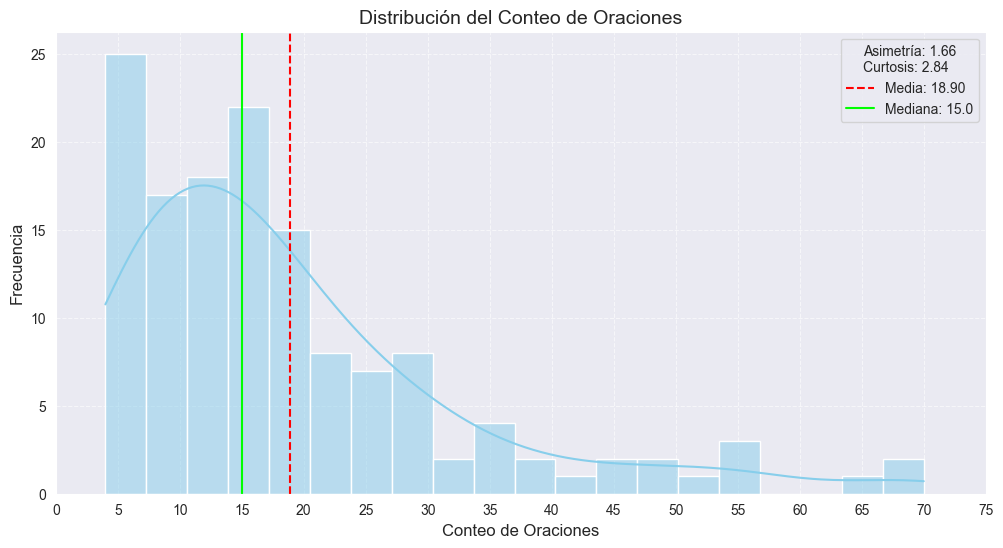

In [24]:
sns.set_style("darkgrid")
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x="sentence_count", bins=20, kde=True, color="skyblue")

# Central tendency lines
plt.axvline(mean_sentences, color='red', linestyle='--', linewidth=1.5, label=f"Media: {mean_sentences:.2f}")
plt.axvline(median_sentences, color='lime', linestyle='-', linewidth=1.5, label=f"Mediana: {median_sentences:.1f}")

# Labels and info
plt.title("Distribución del Conteo de Oraciones", fontsize=14)
plt.xlabel("Conteo de Oraciones", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
ticks = np.arange(0, plt.xlim()[1] + 5, 5)
plt.xticks(ticks)
plt.legend(title=f"Asimetría: {skewness_sentences:.2f}\nCurtosis: {kurtosis_sentences:.2f}")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### Paso 1.3.1: Interpretación de la Distribución del Conteo de Oraciones

La gráfica muestra la distribución del número de oraciones por artículo de noticias, con una clara concentración entre 5 y 20 oraciones. Esta distribución presenta una asimetría positiva (asimetría = 1.66), lo que indica que la mayoría de los artículos tienden a ser breves, mientras que unos pocos tienen una cantidad significativamente mayor de oraciones. La media (18.90) es superior a la mediana (15.0), lo cual refuerza esta tendencia. La curtosis (2.84) sugiere una forma algo más apuntada con colas moderadamente pesadas. En conjunto, estos datos reflejan que la mayoría de los artículos de noticias analizados son cortos, aunque existen algunos que presentan una extensión considerablemente mayor.

### Paso 1.4: longitud promedio de palabra

In [25]:
mean_average_word_length = df["average_word_length"].mean()
median_average_word_length = df["average_word_length"].median()
skewness_average_word_length = df["average_word_length"].skew()
kurtosis_average_word_length = df["average_word_length"].kurt()

In [26]:
print(f"Media (Mean): {mean_average_word_length:.2f}")
print(f"Mediana (Median): {median_average_word_length}")
print(f"Asimetría (Skewness): {skewness_average_word_length:.2f}")
print(f"Curtosis (Kurtosis): {kurtosis_average_word_length:.2f}")

Media (Mean): 5.08
Mediana (Median): 5.07036396520086
Asimetría (Skewness): -0.10
Curtosis (Kurtosis): 0.86


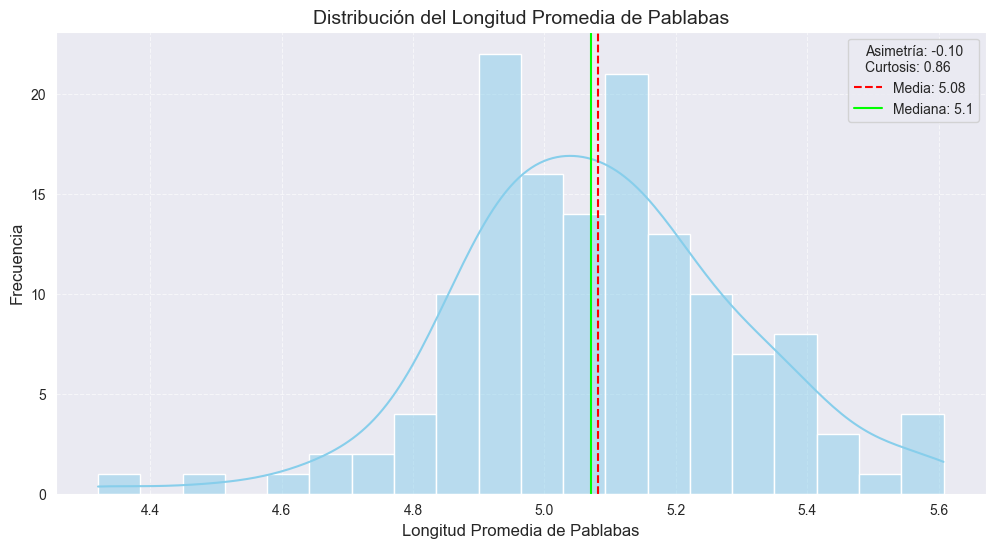

In [27]:
sns.set_style("darkgrid")
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x="average_word_length", bins=20, kde=True, color="skyblue")

# Central tendency lines
plt.axvline(mean_average_word_length, color='red', linestyle='--', linewidth=1.5, label=f"Media: {mean_average_word_length:.2f}")
plt.axvline(median_average_word_length, color='lime', linestyle='-', linewidth=1.5, label=f"Mediana: {median_average_word_length:.1f}")

# Labels and info
plt.title("Distribución del Longitud Promedia de Pablabas", fontsize=14)
plt.xlabel("Longitud Promedia de Pablabas", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.legend(title=f"Asimetría: {skewness_average_word_length:.2f}\nCurtosis: {kurtosis_average_word_length:.2f}")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### Paso 1.4.1: Interpretación de la Distribución del Conteo de Oraciones

La gráfica muestra la distribución de la longitud promedio de palabras en artículos de noticias. Se puede observar que hay una concentración entre 4.8 y 5.4 caracteres, lo que indica que la mayoría de los textos utilizan palabras de longitud media. La distribución es casi simétrica, con una ligera asimetría negativa (-0.10), lo que sugiere que hay una leve tendencia hacia palabras más cortas. La media (5.08) y la mediana (5.1) están prácticamente alineadas, lo que refuerza esta simetría. La curtosis (0.86) indica que la distribución es algo más plana que una distribución normal. En conjunto, los datos sugieren un uso consistente de palabras de longitud media en los artículos analizados.

## Paso 2: Tokenización

### Paso 2.1: Word Tokenization

In [28]:
df["word_tokens"] = df["news"].apply(lambda text: word_tokenize(text.lower()))

In [29]:
df["word_tokens"]

0      [¿cuánto, tiempo, estoy, autorizado, a, perman...
1      [colombia, y, venezuela, instalaron, comisión,...
2      [atrasar, proceso, electoral, hasta, enero, de...
3      [avanza, slp, en, cuanto, a, transparencia, pr...
4      [confía, dirigente, del, pt, en, mantener, el,...
                             ...                        
135    [vacaciones, de, terror, :, agencia, de, viaje...
136    [en, slp, ,, la, gasolina, más, barata, se, ve...
137    [inflación, baja, a, 4.79, %, en, la, primera,...
138    [reducción, de, jornada, laboral, provocará, u...
139    [advierte, ricardo, gallardo, más, cambios, en...
Name: word_tokens, Length: 140, dtype: object

### Paso 2.2: Sentence Tokenization

In [30]:
df["sentence_tokens"] = df["news"].apply(lambda text: sent_tokenize(text))

In [31]:
df["sentence_tokens"]

0      [¿Cuánto tiempo estoy autorizado a permanecer ...
1      [Colombia y Venezuela instalaron comisión de v...
2      [Atrasar proceso electoral hasta enero de 2024...
3      [Avanza SLP en cuanto a transparencia presupue...
4      [Confía dirigente del PT en mantener el regist...
                             ...                        
135    [Vacaciones de terror: agencia de viajes pobla...
136    [En SLP, la gasolina más barata se vende por d...
137    [Inflación baja a 4.79% en la primera mitad de...
138    [Reducción de jornada laboral provocará un des...
139    [Advierte Ricardo Gallardo más cambios en su g...
Name: sentence_tokens, Length: 140, dtype: object

## Paso 3: Análisis de Stopwords

### Paso 3.1: Remover los Stopwords

In [32]:
# Create a set of stop words
spanish_stopwords = set(stopwords.words('spanish'))

In [33]:
# Function to clean text
def clean_text(text):
    words = text.split()
    cleaned_words = [
        re.sub(r'[^a-zA-ZáéíóúüñÁÉÍÓÚÜÑ]', '', word)
        for word in words
        if word.lower() not in spanish_stopwords and word not in string.punctuation
    ]
    return " ".join(cleaned_words)



In [34]:
# Combine all text in the "news" column
text = " ".join(df["news"].dropna())

# Remove punctuation and stopwords
text_cleaned = clean_text(text)


In [35]:
# Grouping by 'principal_frames' without cleaning the concatenated text
frame_texts_raw = {}

for frame, group in df.groupby("principal_frames"):
    combined_text = " ".join(group["news"].dropna())  # Concatenate text without cleaning
    frame_texts_raw[frame] = combined_text


In [36]:
# Grouping by 'principal_frames' and cleaning the concatenated text
frame_texts_cleaned = {}

for frame, group in df.groupby("principal_frames"):
    combined_text = " ".join(group["news"].dropna())  # Concatenate text
    cleaned = clean_text(combined_text)  # Apply the cleaning function
    frame_texts_cleaned[frame] = cleaned


### Paso 3.2: Frecuencia de los Stopwords

#### Paso 3.2.1: Frecuencia de los Stopwords en general

In [37]:
all_tokens = text.split()

In [38]:
stopword_counts = Counter([word for word in all_tokens if word in spanish_stopwords])

In [39]:
# Convert to DataFrame for visualization
df_stopwords = (pd.DataFrame(stopword_counts.items(), columns=['Stopword', 'Frequency'])
                .sort_values(by='Frequency', ascending=False)
                .head(20))

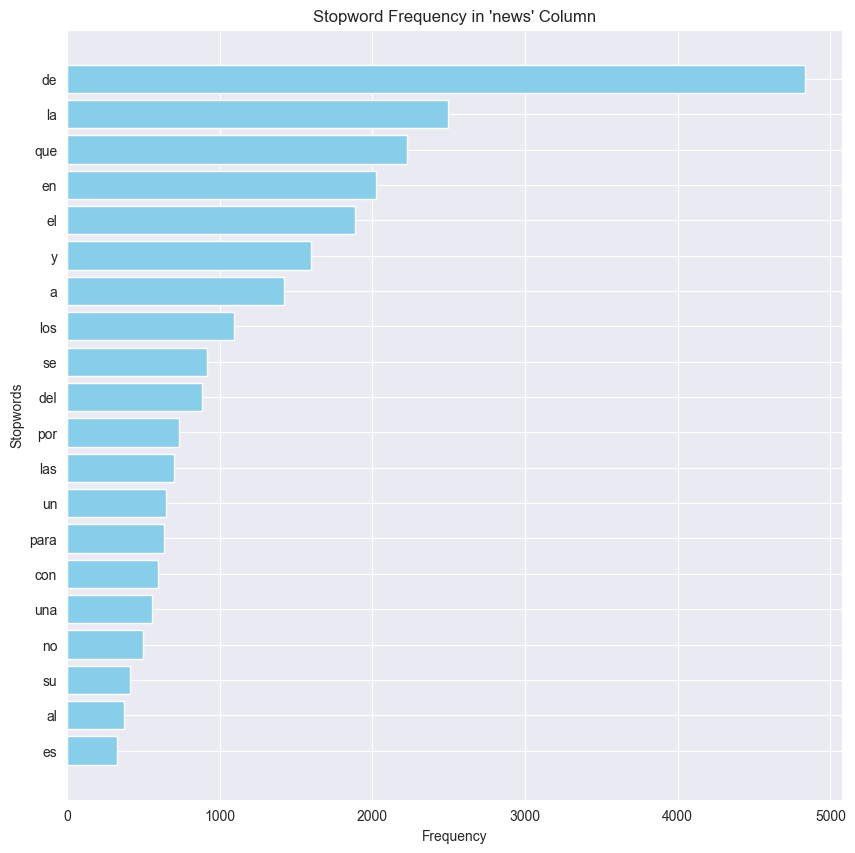

In [40]:
# Plot the stopword frequency
plt.figure(figsize=(10, 10))
plt.barh(df_stopwords['Stopword'], df_stopwords['Frequency'], color='skyblue')
plt.xlabel("Frequency")
plt.ylabel("Stopwords")
plt.title("Stopword Frequency in 'news' Column")
plt.gca().invert_yaxis()  # Invert to show the highest frequency on top
plt.show()

Este gráfico muestra las palabras vacías más frecuentes en la columna `news` de un conjunto de datos en español. Se observa que palabras como “de”, “la”, “que”, “en” y “el” son las más comunes, lo cual es esperable ya que son términos funcionales del idioma que no aportan mucho contenido semántico. Estas palabras suelen eliminarse en tareas de procesamiento de lenguaje natural para centrarse en términos más significativos. Por tanto, este análisis revela la necesidad de una limpieza del texto antes de aplicar técnicas más avanzadas como clasificación, extracción de temas o análisis de sentimientos.

#### Paso 3.2.2: Frecuencia de los Stopwords por tema

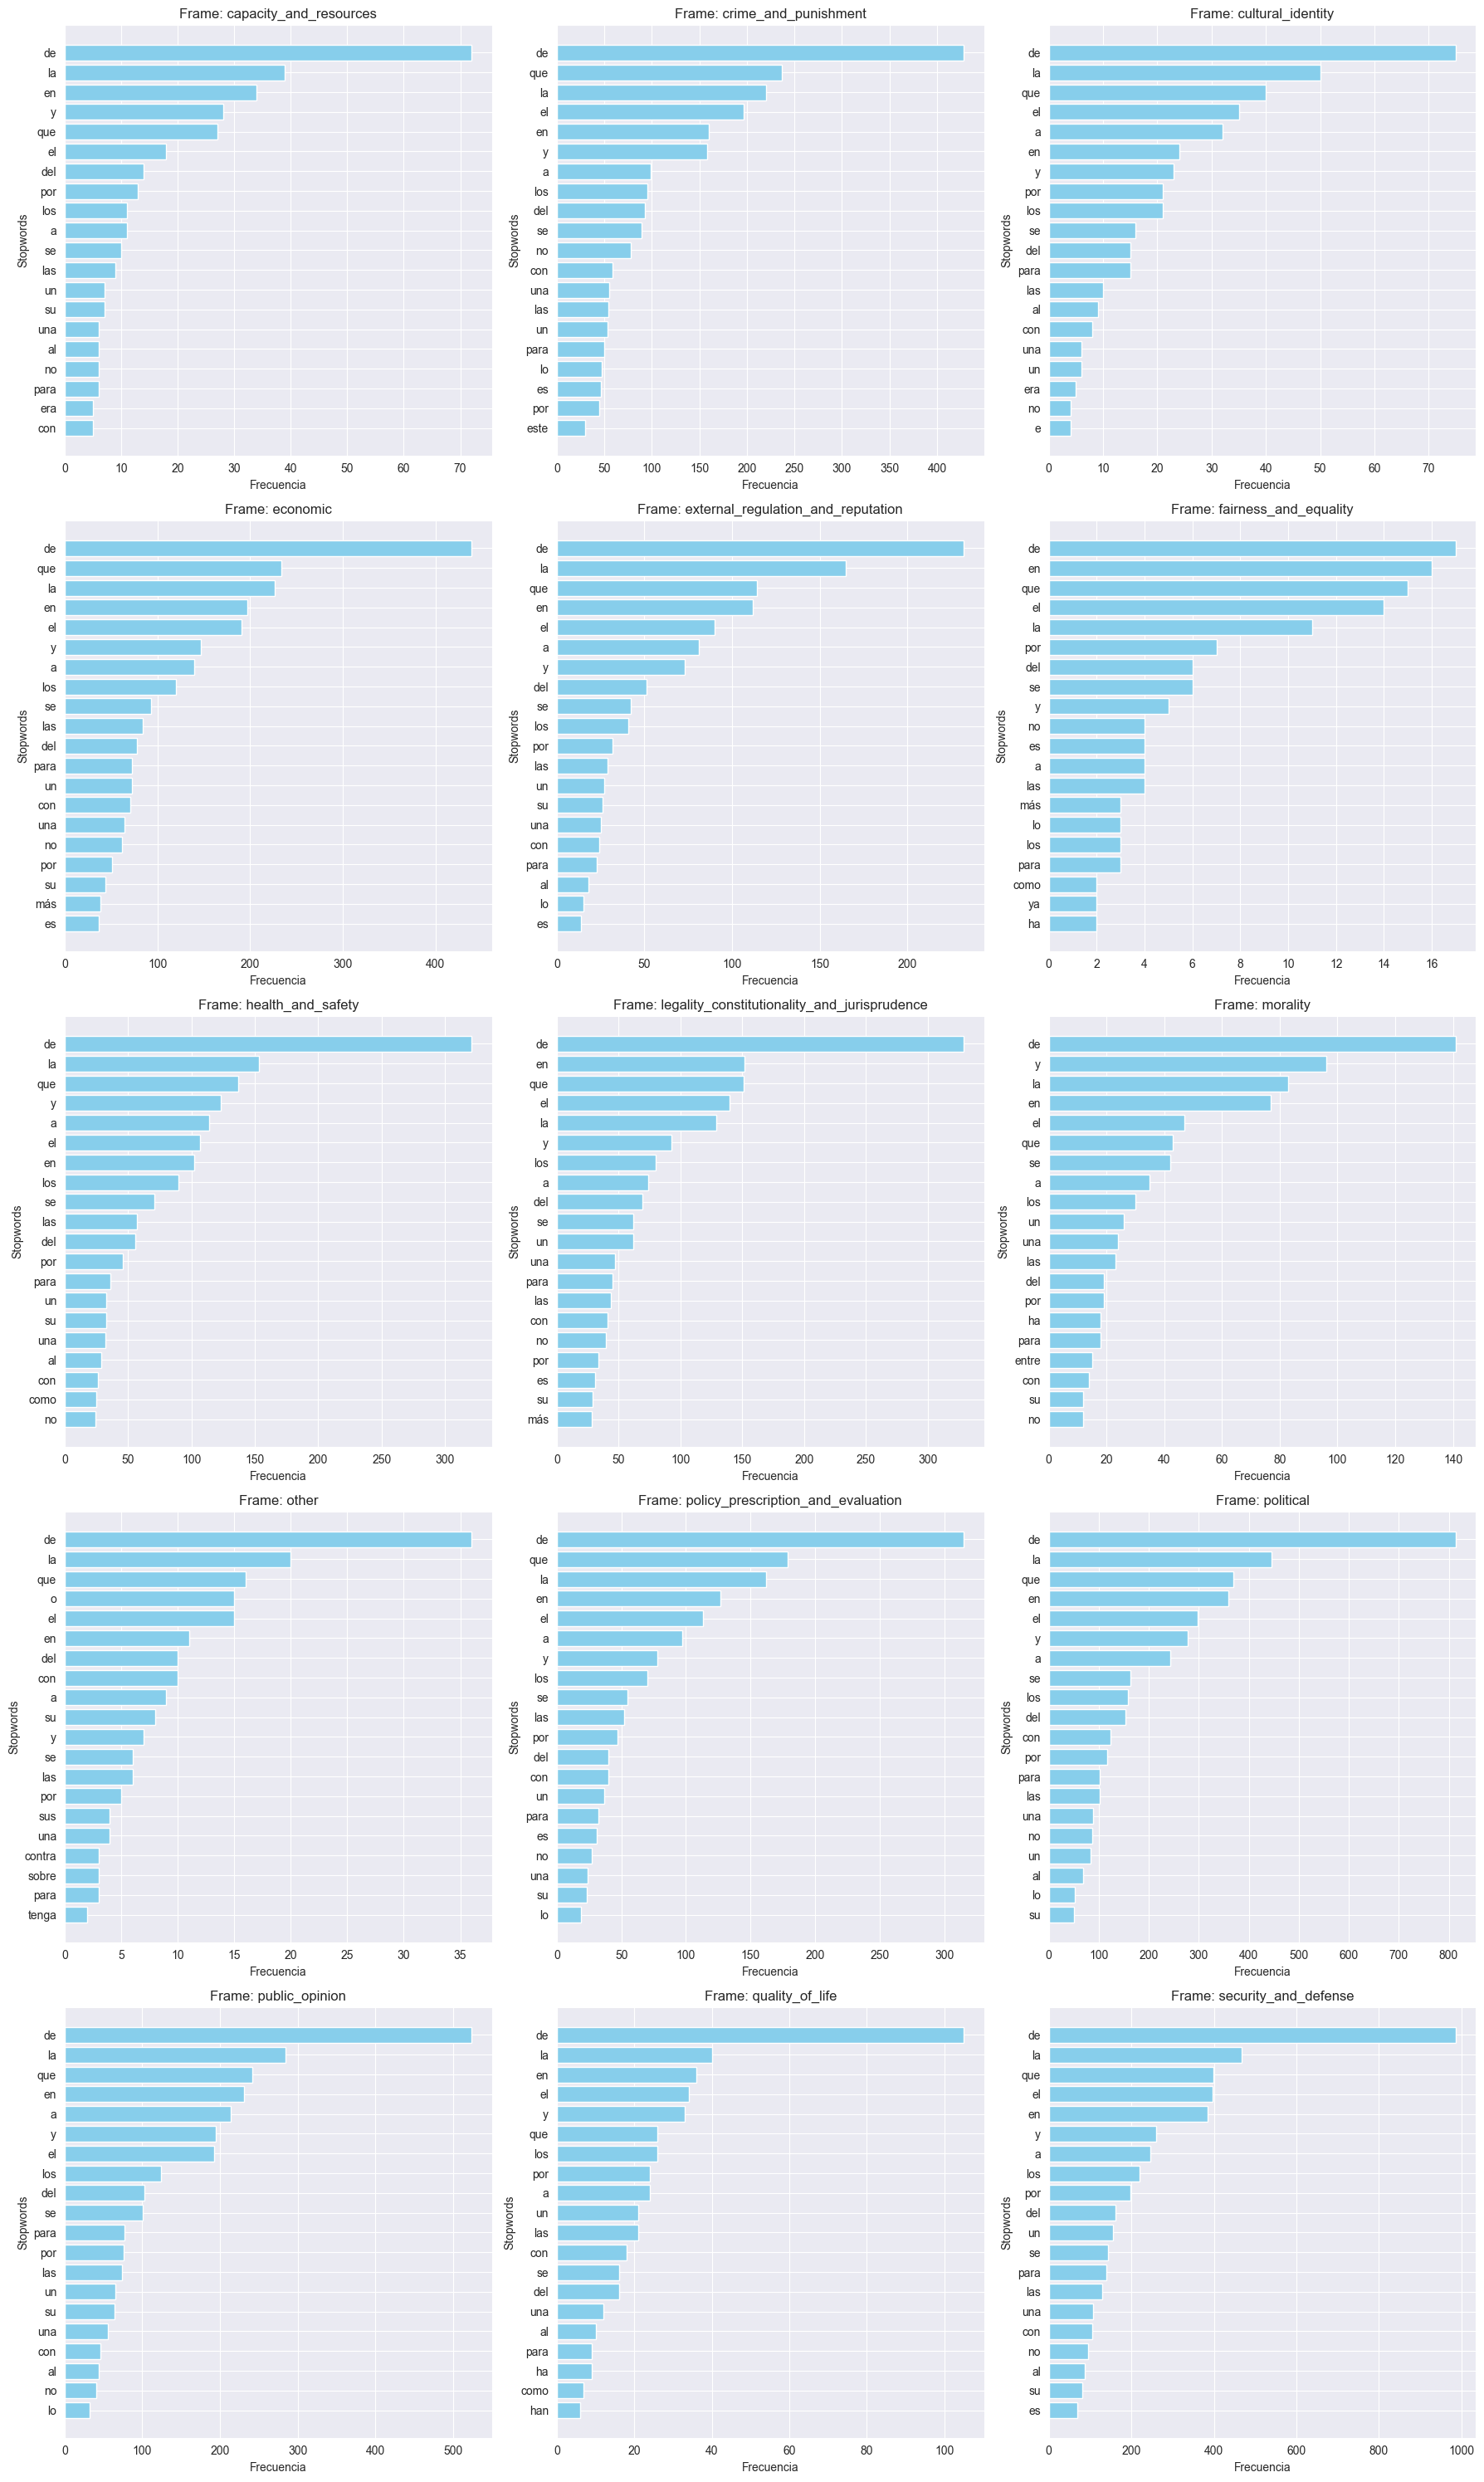

In [41]:
# Paso 2: Preparar el diseño de los sub gráficos
n_frames = len(frame_texts_raw)  # Número de frames a visualizar
cols = 3  # Número de columnas (puede ser 3 para un diseño más compacto)
rows = math.ceil(n_frames / cols)  # Calcular filas necesarias

# Crear figura y ejes (subgráficos)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 6))
axes = axes.flatten()  # Convertir a array 1D para facilitar el acceso

# Paso 3: Graficar cada frame
for idx, (frame, frame_text_cleaned) in enumerate(frame_texts_raw.items()):
    # Contar stopwords en el texto
    all_tokens = frame_text_cleaned.split()
    stopword_counts = Counter([word for word in all_tokens if word in spanish_stopwords])

    # Crear DataFrame ordenado por frecuencia
    df_stopwords = (
        pd.DataFrame(stopword_counts.items(), columns=['Stopword', 'Frecuencia'])
        .sort_values(by='Frecuencia', ascending=False)
        .head(20)  # Tomar las 20 stopwords más frecuentes
    )

    # Configurar el subgráfico actual
    ax = axes[idx]
    ax.barh(df_stopwords['Stopword'], df_stopwords['Frecuencia'], color='skyblue')
    ax.set_title(f"Frame: {frame}")  # Título con el nombre del frame
    ax.set_xlabel("Frecuencia")      # Etiqueta eje X
    ax.set_ylabel("Stopwords")       # Etiqueta eje Y
    ax.invert_yaxis()  # Invertir eje Y para mostrar mayor frecuencia arriba

# Paso 4: Ocultar subgráficos no utilizados
for ax in axes[n_frames:]:
    ax.axis("off")  # Desactivar ejes en subgráficos vacíos

# Ajustar diseño y mostrar
plt.tight_layout()
plt.show()

El conjunto de gráficos muestra la frecuencia de las palabras vacías más comunes en diferentes categorías temáticas o *frames* (como "crime_and_punishment", "economic", "health_and_safety", "political", entre otros), dentro de una columna de texto en español. A lo largo de todos los marcos temáticos, se observa que las palabras "de", "la", "que", "el", "y" y "en" se repiten con alta frecuencia, lo que refleja su naturaleza como conectores comunes en el idioma. Aunque estas palabras no aportan contenido semántico relevante, su análisis previo permite observar patrones de uso lingüístico general en cada marco temático. Este tipo de visualización es útil para comprobar la necesidad de limpiar el texto antes de realizar análisis más profundos, como extracción de temas o clasificación basada en contenido.

## Paso 4: Descripción de Datos en NLP durante el Análisis Exploratorio de Datos

### Paso 4.1: Mostrar textos de ejemplo

### Paso 4.1.1: Ver las primeras filas

In [42]:
df["news"].head()

0    ¿Cuánto tiempo estoy autorizado a permanecer e...
1    Colombia y Venezuela instalaron comisión de ve...
2    Atrasar proceso electoral hasta enero de 2024,...
3    Avanza SLP en cuanto a transparencia presupues...
4    Confía dirigente del PT en mantener el registr...
Name: news, dtype: object

### Paso 4.1.2: Muestras aleatorias

In [43]:
df["news"].sample(5, random_state=42)

108    ¿Cómo es que Ecuador se está volviendo en terr...
67     El contrapunteo entre Gustavo Petro e Iván Duq...
31     México y EU sostienen reunión por fentanilo en...
119    Celebridades están en líos por promocionar cri...
42     Burocracia del gobierno estadounidense retrasa...
Name: news, dtype: object

### Paso 4.2: Estadísticas resumidas básicas

#### Paso 4.2.1: Distribución de la longitud del texto

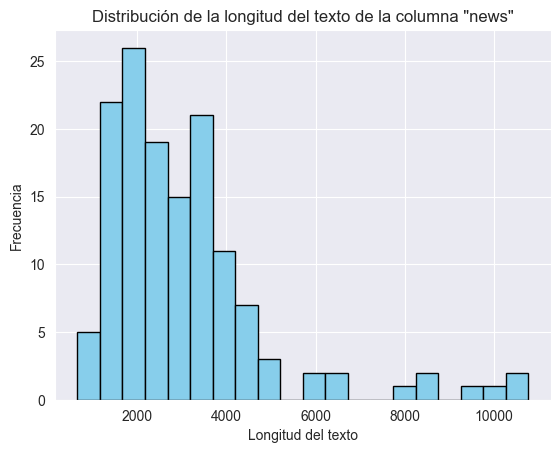

In [44]:
df['text_length'] = df['news'].apply(len)

# Graficar la distribución de la longitud del texto
plt.hist(df['text_length'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribución de la longitud del texto de la columna "news"')
plt.xlabel('Longitud del texto')
plt.ylabel('Frecuencia')
plt.show()

#### Paso 4.2.2: Frecuencia de palabras

In [45]:
# Separar en palabras y contar la frecuencia
word_freq = Counter(text_cleaned.split())

# Convertir a DataFrame para visualizar
word_freq_df = pd.DataFrame(word_freq.items(), columns=['Palabra', 'Frecuencia']).sort_values(by='Frecuencia', ascending=False)

# Mostrar las 10 palabras más frecuentes
print(word_freq_df.head(20))

         Palabra  Frecuencia
572         dijo         138
172         años         131
304     personas         118
1328  presidente         110
1193    gobierno         103
209          dos          99
230          año          94
616        parte          93
489       ciento          93
509          mil          86
4         Unidos          82
137     Nacional          79
73          país          78
674       México          76
37            si          75
510     millones          73
511        pesos          72
231       pasado          70
630        López          69
1291       Petro          69


#### Paso 4.2.3: Estadísticas de la longitud de los documentos

In [46]:
media_dls = df['text_length'].mean()
mediana_dls = df['text_length'].median()
desviacion_dls = df['text_length'].std()
minimo_dls = df['text_length'].min()
maximo_dls = df['text_length'].max()

print("Estadísticas de la longitud de los documentos [df['text_length']]:")
print(f"Media: {media_dls:.2f}")
print(f"Mediana: {mediana_dls}")
print(f"Desviación estándar: {desviacion_dls:.2f}")
print(f"Mínimo: {minimo_dls}")
print(f"Máximo: {maximo_dls}")

Estadísticas de la longitud de los documentos [df['text_length']]:
Media: 3062.86
Mediana: 2626.0
Desviación estándar: 1861.50
Mínimo: 666
Máximo: 10760


### Paso 4.3: Tipos de datos y estructura

#### Paso 4.3.1: Tipos de datos

In [47]:
df.dtypes

id                                               object
news                                             object
frames                                           object
tone                                             object
principal_frames                                 object
economic                                          int64
capacity_and_resources                            int64
morality                                          int64
fairness_and_equality                             int64
legality_constitutionality_and_jurisprudence      int64
policy_prescription_and_evaluation                int64
crime_and_punishment                              int64
security_and_defense                              int64
health_and_safety                                 int64
quality_of_life                                   int64
cultural_identity                                 int64
public_opinion                                    int64
political                                       

## Paso 5: Visualización de Datos en NLP para el Análisis Exploratorio de Datos

### Paso 5.1: Nubes de Palabras

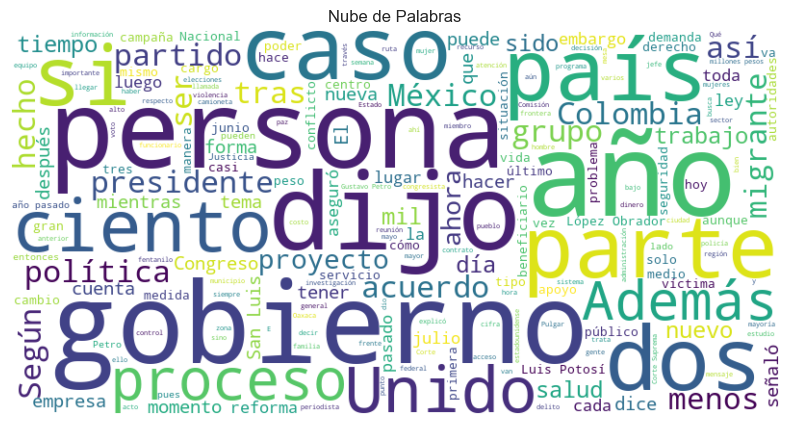

In [48]:
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text_cleaned)
plt.figure(figsize=(10, 5))
plt.title("Nube de Palabras")
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

La nube de palabras muestra que los temas más comunes en el corpus giran en torno a gobierno, persona, caso, dos, país, año, y dijo. Esto sugiere un enfoque fuerte en narrativas relacionadas con la acción gubernamental, las experiencias individuales y eventos específicos. Palabras como gobierno y país indican que el discurso se centra en asuntos políticos y nacionales, mientras que caso y proceso apuntan a situaciones legales o procedimientos importantes. La mención de dos y año sugiere comparaciones o referencias a periodos de tiempo, y el verbo dijo destaca la importancia de declaraciones o testimonios en el contenido. En cuanto a Unido, parece hacer referencia probablemente a nombres compuestos de lugares o entidades como Estados Unidos, pero de manera fragmentada en el texto.

### Paso 5.2: Frequency Distribution Plots

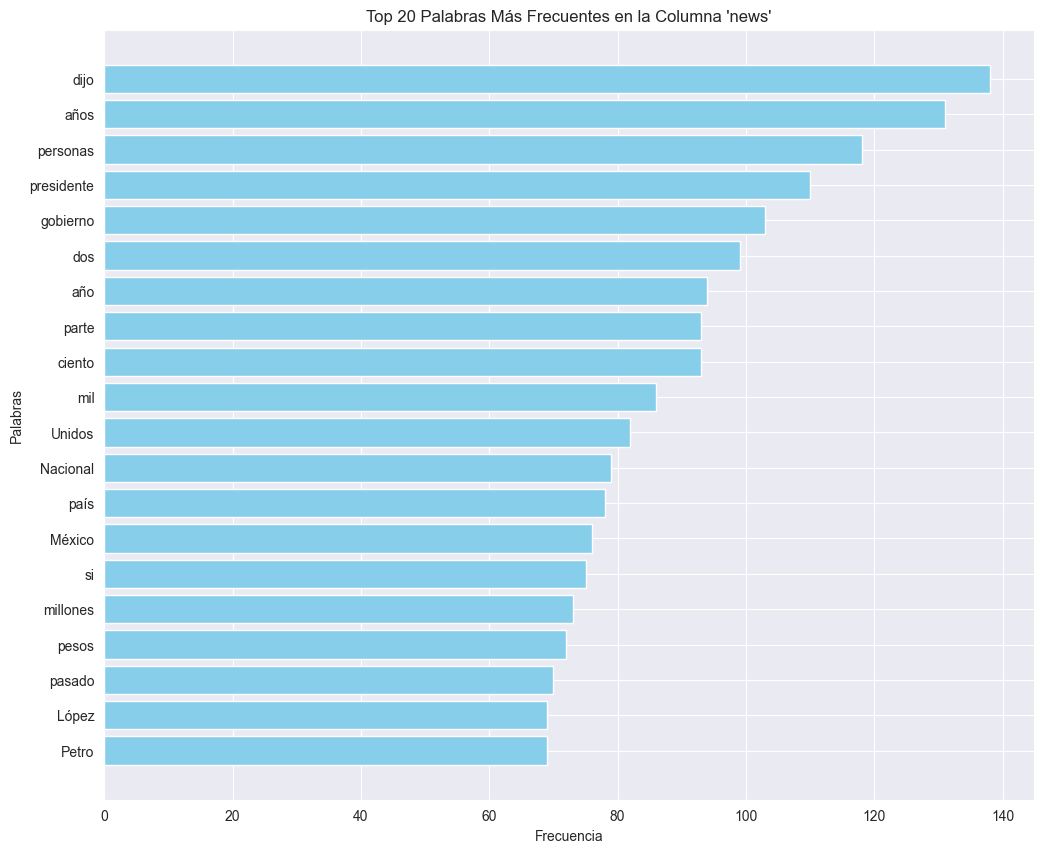

In [49]:
# Tokenizar el texto limpio
tokens = word_tokenize(text_cleaned)

# Contar frecuencias de palabras
contador_palabras = Counter(tokens)

# Convertir a DataFrame y ordenar por frecuencia
df_frecuencia_palabras = (pd.DataFrame(contador_palabras.items(), columns=['Palabra', 'Frecuencia'])
                         .sort_values(by='Frecuencia', ascending=False))

# Seleccionar las N palabras más frecuentes (ej. 20)
N = 20
palabras_principales = df_frecuencia_palabras.head(N)

# Graficar gráfico de barras horizontales
plt.figure(figsize=(12, 10))
plt.barh(palabras_principales['Palabra'], palabras_principales['Frecuencia'], color='skyblue')
plt.xlabel("Frecuencia")
plt.ylabel("Palabras")
plt.title(f"Top {N} Palabras Más Frecuentes en la Columna 'news'")
plt.gca().invert_yaxis()  # La frecuencia más alta arriba
plt.show()

El análisis de frecuencia de palabras en artículos de noticias de Colombia y México revela que los temas más recurrentes giran en torno a declaraciones (**dijo**), temporalidades (**años**, **año**, **pasado**), actores sociales (**personas**, **presidente**, **gobierno**), y cifras o cantidades (**ciento**, **mil**, **millones**, **pesos**). Además, se observa una referencia constante a lugares como **México**, **Colombia** y términos como **Unidos** (probablemente en el contexto de **Estados Unidos**). La presencia de palabras como **Nacional** y **país** resalta el enfoque en asuntos de carácter político y social, mientras que nombres propios como **López** reflejan la mención de figuras relevantes en las noticias. En conjunto, estos términos sugieren un fuerte interés en reportajes sobre política, economía y sociedad en ambos países.

### Paso 5.3: El análisis de N-grams

In [50]:
def clean_text(text):
    """
    Limpia el texto eliminando signos de puntuación, números, stopwords y convirtiendo a minúsculas.
    """
    # Convertir a minúsculas
    text = text.lower()

    # Eliminar signos de puntuación
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text)

    # Eliminar números
    text = re.sub(r'\d+', '', text)

    # Eliminar stopwords
    stop_words = set(stopwords.words('spanish'))  # Cambia 'spanish' por el idioma que necesites
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words and word.isalpha()]  # Solo palabras alfabéticas

    return tokens

In [51]:
def generate_ngramas(text, n):
    """
    Genera n-gramas a partir de un texto limpio.
    """
    # Limpiar el texto
    tokens = clean_text(text)

    # Generar n-gramas
    return list(ngrams(tokens, n))

#### Paso 5.3.1: Bigrams

In [52]:
# Aplicar la función a cada fila de la columna 'news'
df['bigramas'] = df['news'].apply(lambda x: generate_ngramas(x, 2))

C:\Users\guill\AppData\Local\Temp\ipykernel_12264\1592844729.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_frecuencia, x='Bigrama', y='Frecuencia', palette='viridis')


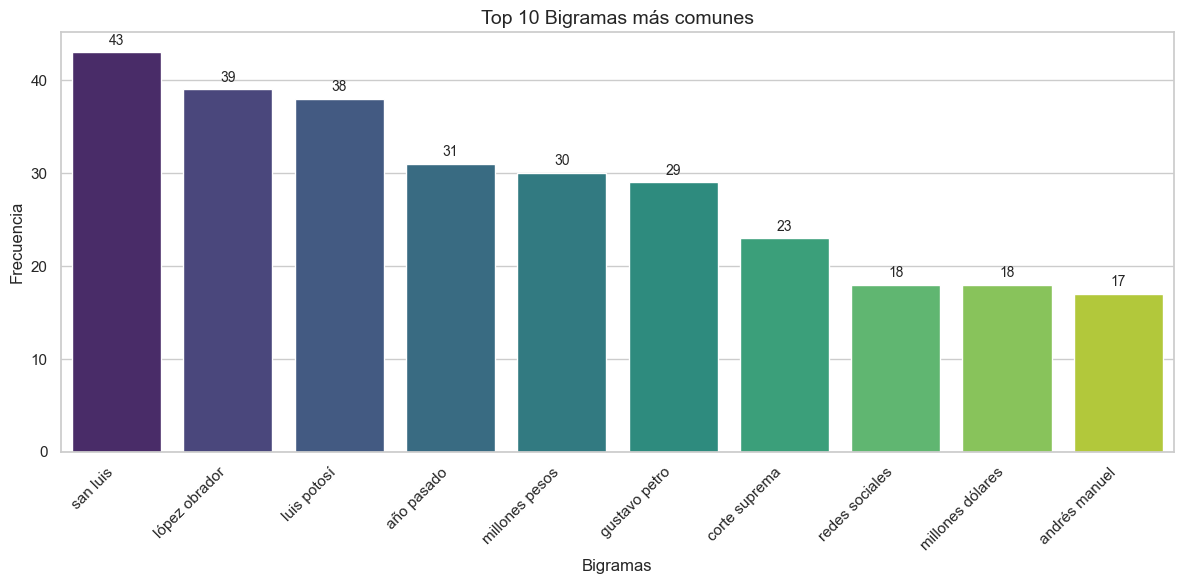

In [53]:
# Combinar todos los n-gramas en una sola lista
todos_los_bigramas = [bigrama for sublist in df['bigramas'] for bigrama in sublist]

# Contar la frecuencia de cada n-grama
frecuencia_bigramas = Counter(todos_los_bigramas)

# Convertir a DataFrame para facilitar la visualización
df_frecuencia = pd.DataFrame(frecuencia_bigramas.most_common(10), columns=['Bigrama', 'Frecuencia'])
df_frecuencia['Bigrama'] = df_frecuencia['Bigrama'].apply(lambda x: ' '.join(x))

# Estilo de seaborn
sns.set(style="whitegrid")

# Graficar
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df_frecuencia, x='Bigrama', y='Frecuencia', palette='viridis')

# Añadir valores sobre las barras
for i, v in enumerate(df_frecuencia['Frecuencia']):
    ax.text(i, v + 0.5, str(v), ha='center', va='bottom', fontsize=10)

plt.xlabel('Bigramas', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.title('Top 10 Bigramas más comunes', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

La gráfica muestra los 10 bigramas más frecuentes en el corpus analizado, reflejando una fuerte presencia de temas políticos, económicos y sociales. Destacan nombres propios como "san luis", "lópez obrador", "luis potosí" y "andrés manuel", lo que sugiere un enfoque importante en figuras públicas y lugares relevantes, principalmente en México. También aparecen términos asociados a la economía como "millones pesos" y "millones dólares", así como menciones a instituciones y actores políticos internacionales como "gustavo petro" y "corte suprema". La presencia de "redes sociales" indica la relevancia de los medios digitales en el contenido. En conjunto, el análisis revela que las conversaciones o noticias están dominadas por temas de interés público y coyuntura política-económica.

#### Paso 5.3.2: Trigrams

In [54]:
df['trigrams'] = df['news'].apply(lambda x: generate_ngramas(x, 3))

C:\Users\guill\AppData\Local\Temp\ipykernel_12264\1574928106.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Trigrama', y='Frecuencia', data=df_trigram_frequency, palette='viridis')


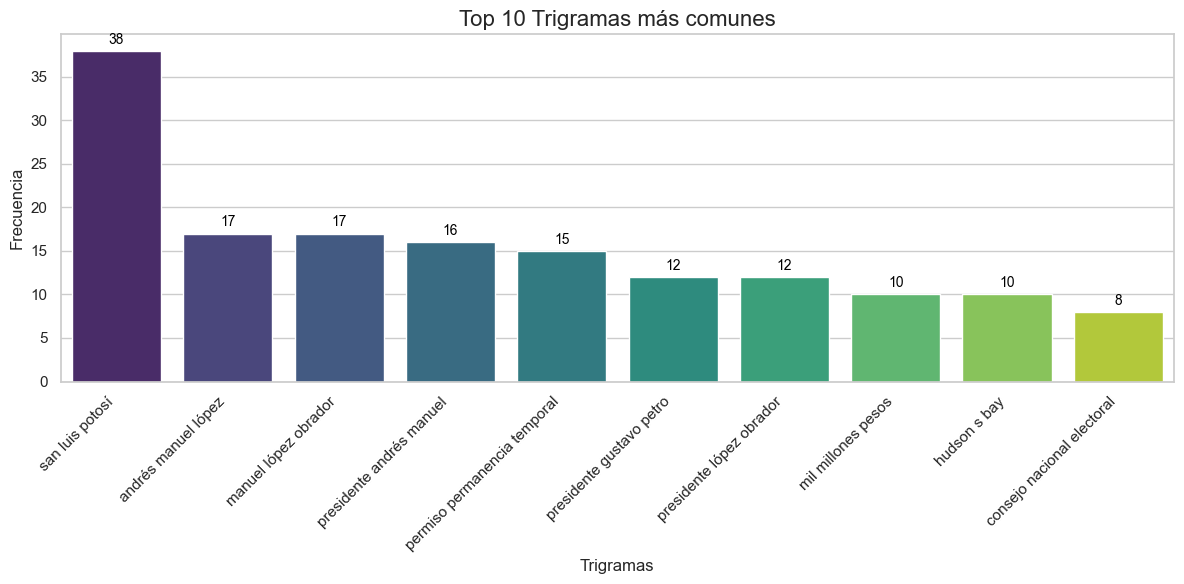

In [55]:
# Combinar todos los n-gramas en una sola lista
todos_los_trigrams = [trigram for sublist in df['trigrams'] for trigram in sublist]

# Contar la frecuencia de cada n-grama
frecuencia_trigrams = Counter(todos_los_trigrams)

# Convertir a DataFrame para facilitar la visualización
df_trigram_frequency = pd.DataFrame(frecuencia_trigrams.most_common(10), columns=['Trigrama', 'Frecuencia'])
df_trigram_frequency['Trigrama'] = df_trigram_frequency['Trigrama'].apply(lambda x: ' '.join(x))

# Graficar con estilo seaborn
plt.figure(figsize=(12, 6))
sns.barplot(x='Trigrama', y='Frecuencia', data=df_trigram_frequency, palette='viridis')

# Agregar etiquetas en las barras
for index, row in df_trigram_frequency.iterrows():
    plt.text(index, row['Frecuencia'] + 0.5, row['Frecuencia'], color='black', ha="center", va="bottom", fontsize=10)

plt.xlabel('Trigramas', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.title('Top 10 Trigramas más comunes', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

La distribución de trigramas revela que el contenido gira en torno a lugares, figuras políticas y temas económicos y migratorios: “san luis potosí” es el más frecuente, seguido por distintas formas de nombrar al presidente mexicano (“andrés manuel lópez”, “manuel lópez obrador”, “presidente andrés manuel” y “presidente lópez obrador”), lo que evidencia un fuerte enfoque en la presidencia de López Obrador; el trigramas “permiso permanencia temporal” apunta a debates sobre regulaciones migratorias; aparecen asimismo menciones a actores y organismos políticos internacionales como “presidente gustavo petro” y “consejo nacional electoral”; finalmente, términos como “mil millones pesos” y la referencia corporativa “hudson s bay” denotan interés en magnitudes económicas y empresas relevantes.

### Paso 5.4: Gráficos de Análisis de Sentimientos

#### Paso 5.4.1: Análisis de Sentimientos en general

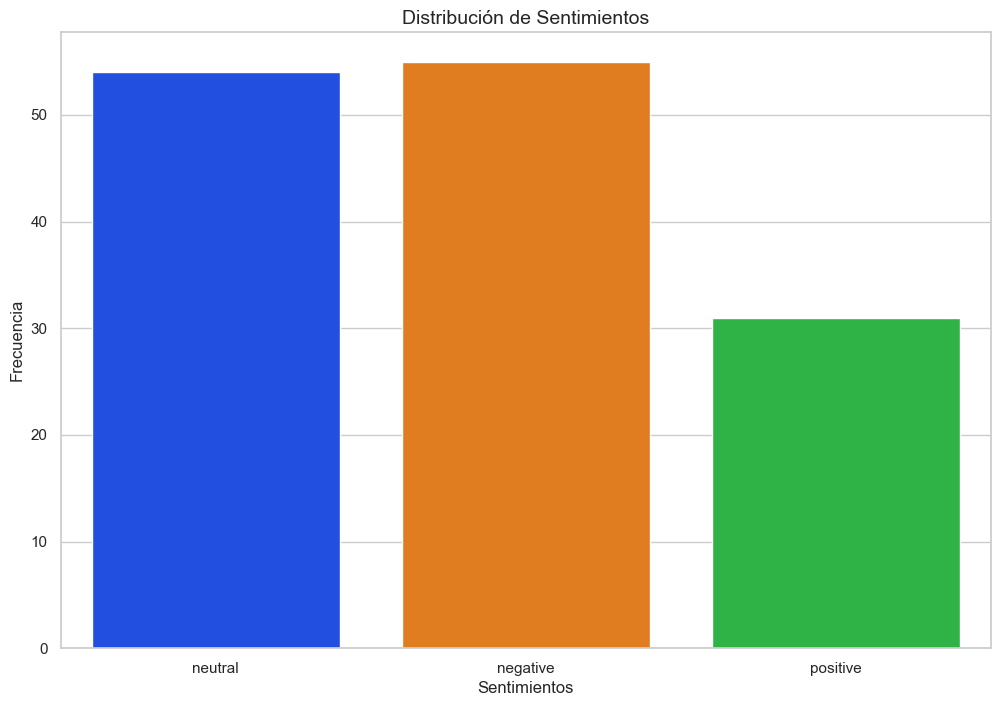

In [56]:
plt.figure(figsize=(12, 8))
sns.countplot(data=df, x="tone", hue="tone", palette="bright", legend=False)
plt.xlabel("Sentimientos", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.title("Distribución de Sentimientos", fontsize=14)
plt.show()

La distribución muestra que, en el conjunto de artículos de noticias de Colombia y México, predominan los tonos neutrales y negativos, con alrededor de 54 menciones neutrales y 55 negativas, frente a unas 31 positivas. Esto sugiere que la cobertura periodística está más orientada a informar de manera objetiva o a destacar problemas, conflictos y situaciones críticas que generan percepciones adversas, mientras que los enfoques optimistas o positivos son menos frecuentes.

#### Paso 5.4.2: Análisis de Sentimientos por tema

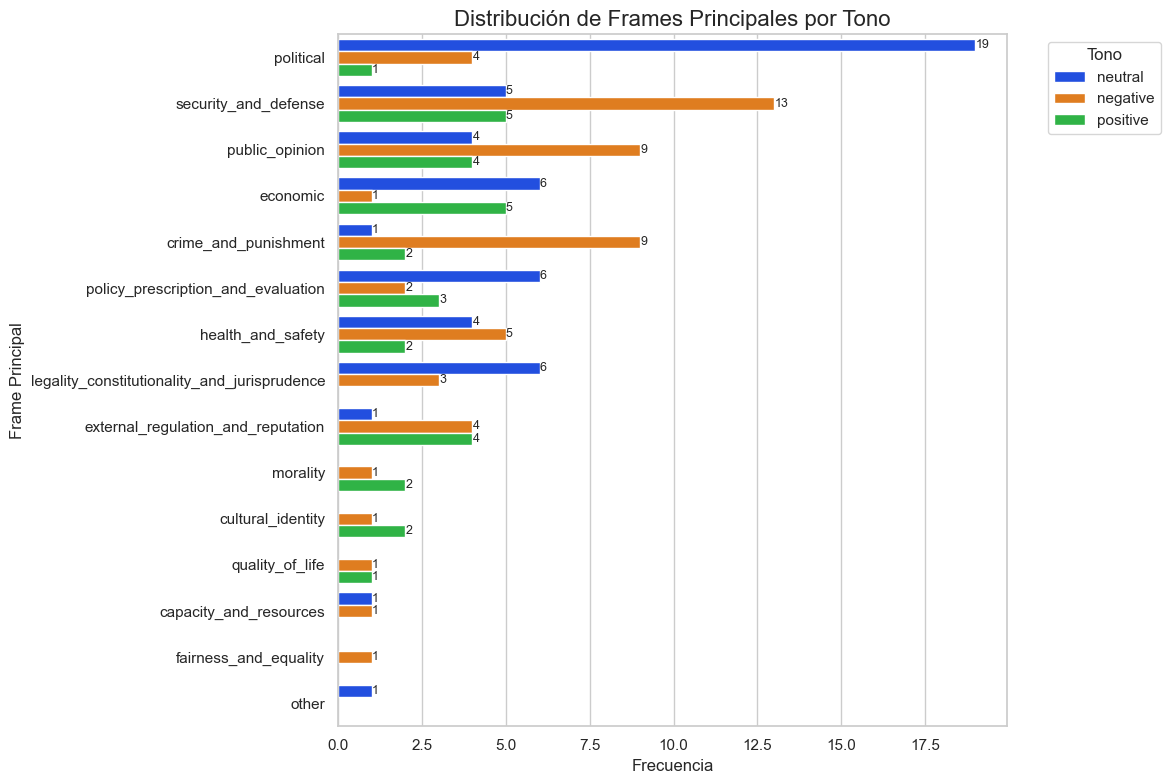

In [57]:
# Sort frames by frequency for better ordering
frame_order = df['principal_frames'].value_counts().index

plt.figure(figsize=(12, 8))
ax = sns.countplot(
    data=df,
    y="principal_frames",
    hue="tone",
    order=frame_order,
    palette="bright"
)

# Add counts to the bars
for container in ax.containers:
    ax.bar_label(container, label_type="edge", fontsize=9)

# Improve aesthetics
plt.title("Distribución de Frames Principales por Tono", fontsize=16)
plt.xlabel("Frecuencia", fontsize=12)
plt.ylabel("Frame Principal", fontsize=12)
plt.legend(title="Tono", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

El gráfico muestra que el **frame “political”** es mayoritariamente tratado en un tono **neutral** (19 menciones), con muy pocas referencias negativas (4) o positivas (1), indicando un abordaje informativo. En cambio, los marcos de **“security_and_defense”** y **“public_opinion”** aparecen sobre todo en **tono negativo** (13 y 9 menciones respectivamente), mientras que el **frame económico** se presenta más en **clave neutral** (6) y **positiva** (5) que negativa (1). El **frame de “crime_and_punishment”** también exhibe fuerte sesgo negativo (9), y otros como **“health_and_safety”** o **“policy_prescription_and_evaluation”** combinan mayoría neutral con un aporte notable de negatividad. En conjunto, los tonos **neutro y negativo** dominan la cobertura, y los énfasis positivos son escasos, lo que sugiere un periodismo especialmente centrado en informar hechos y resaltar problemas.

### Paso 5.5: Named Entity Recognition (NER)

#### Paso 5.5.1: Distribuciones de los NER Tags en general

In [58]:
# Load Spanish spaCy model
nlp = spacy.load("es_core_news_lg")
doc = nlp(text_cleaned)

In [59]:
# Extract entity labels
entities = [ent.label_ for ent in doc.ents]
entity_counts = Counter(entities)

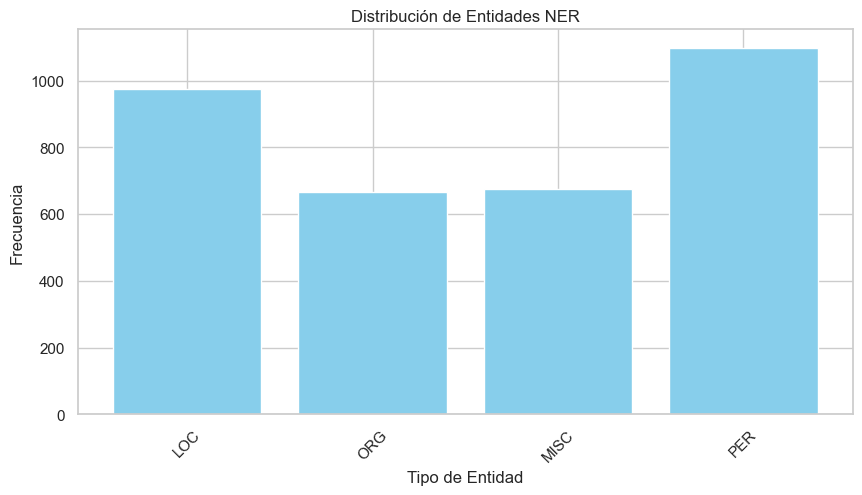

In [60]:
# Bar chart for entity distribution
plt.figure(figsize=(10, 5))
plt.bar(entity_counts.keys(), entity_counts.values(), color='skyblue')
plt.xlabel("Tipo de Entidad")
plt.ylabel("Frecuencia")
plt.title("Distribución de Entidades NER")
plt.xticks(rotation=45)
plt.show()

#### Paso 5.5.2: Distribuciones de los NER Tags por tema

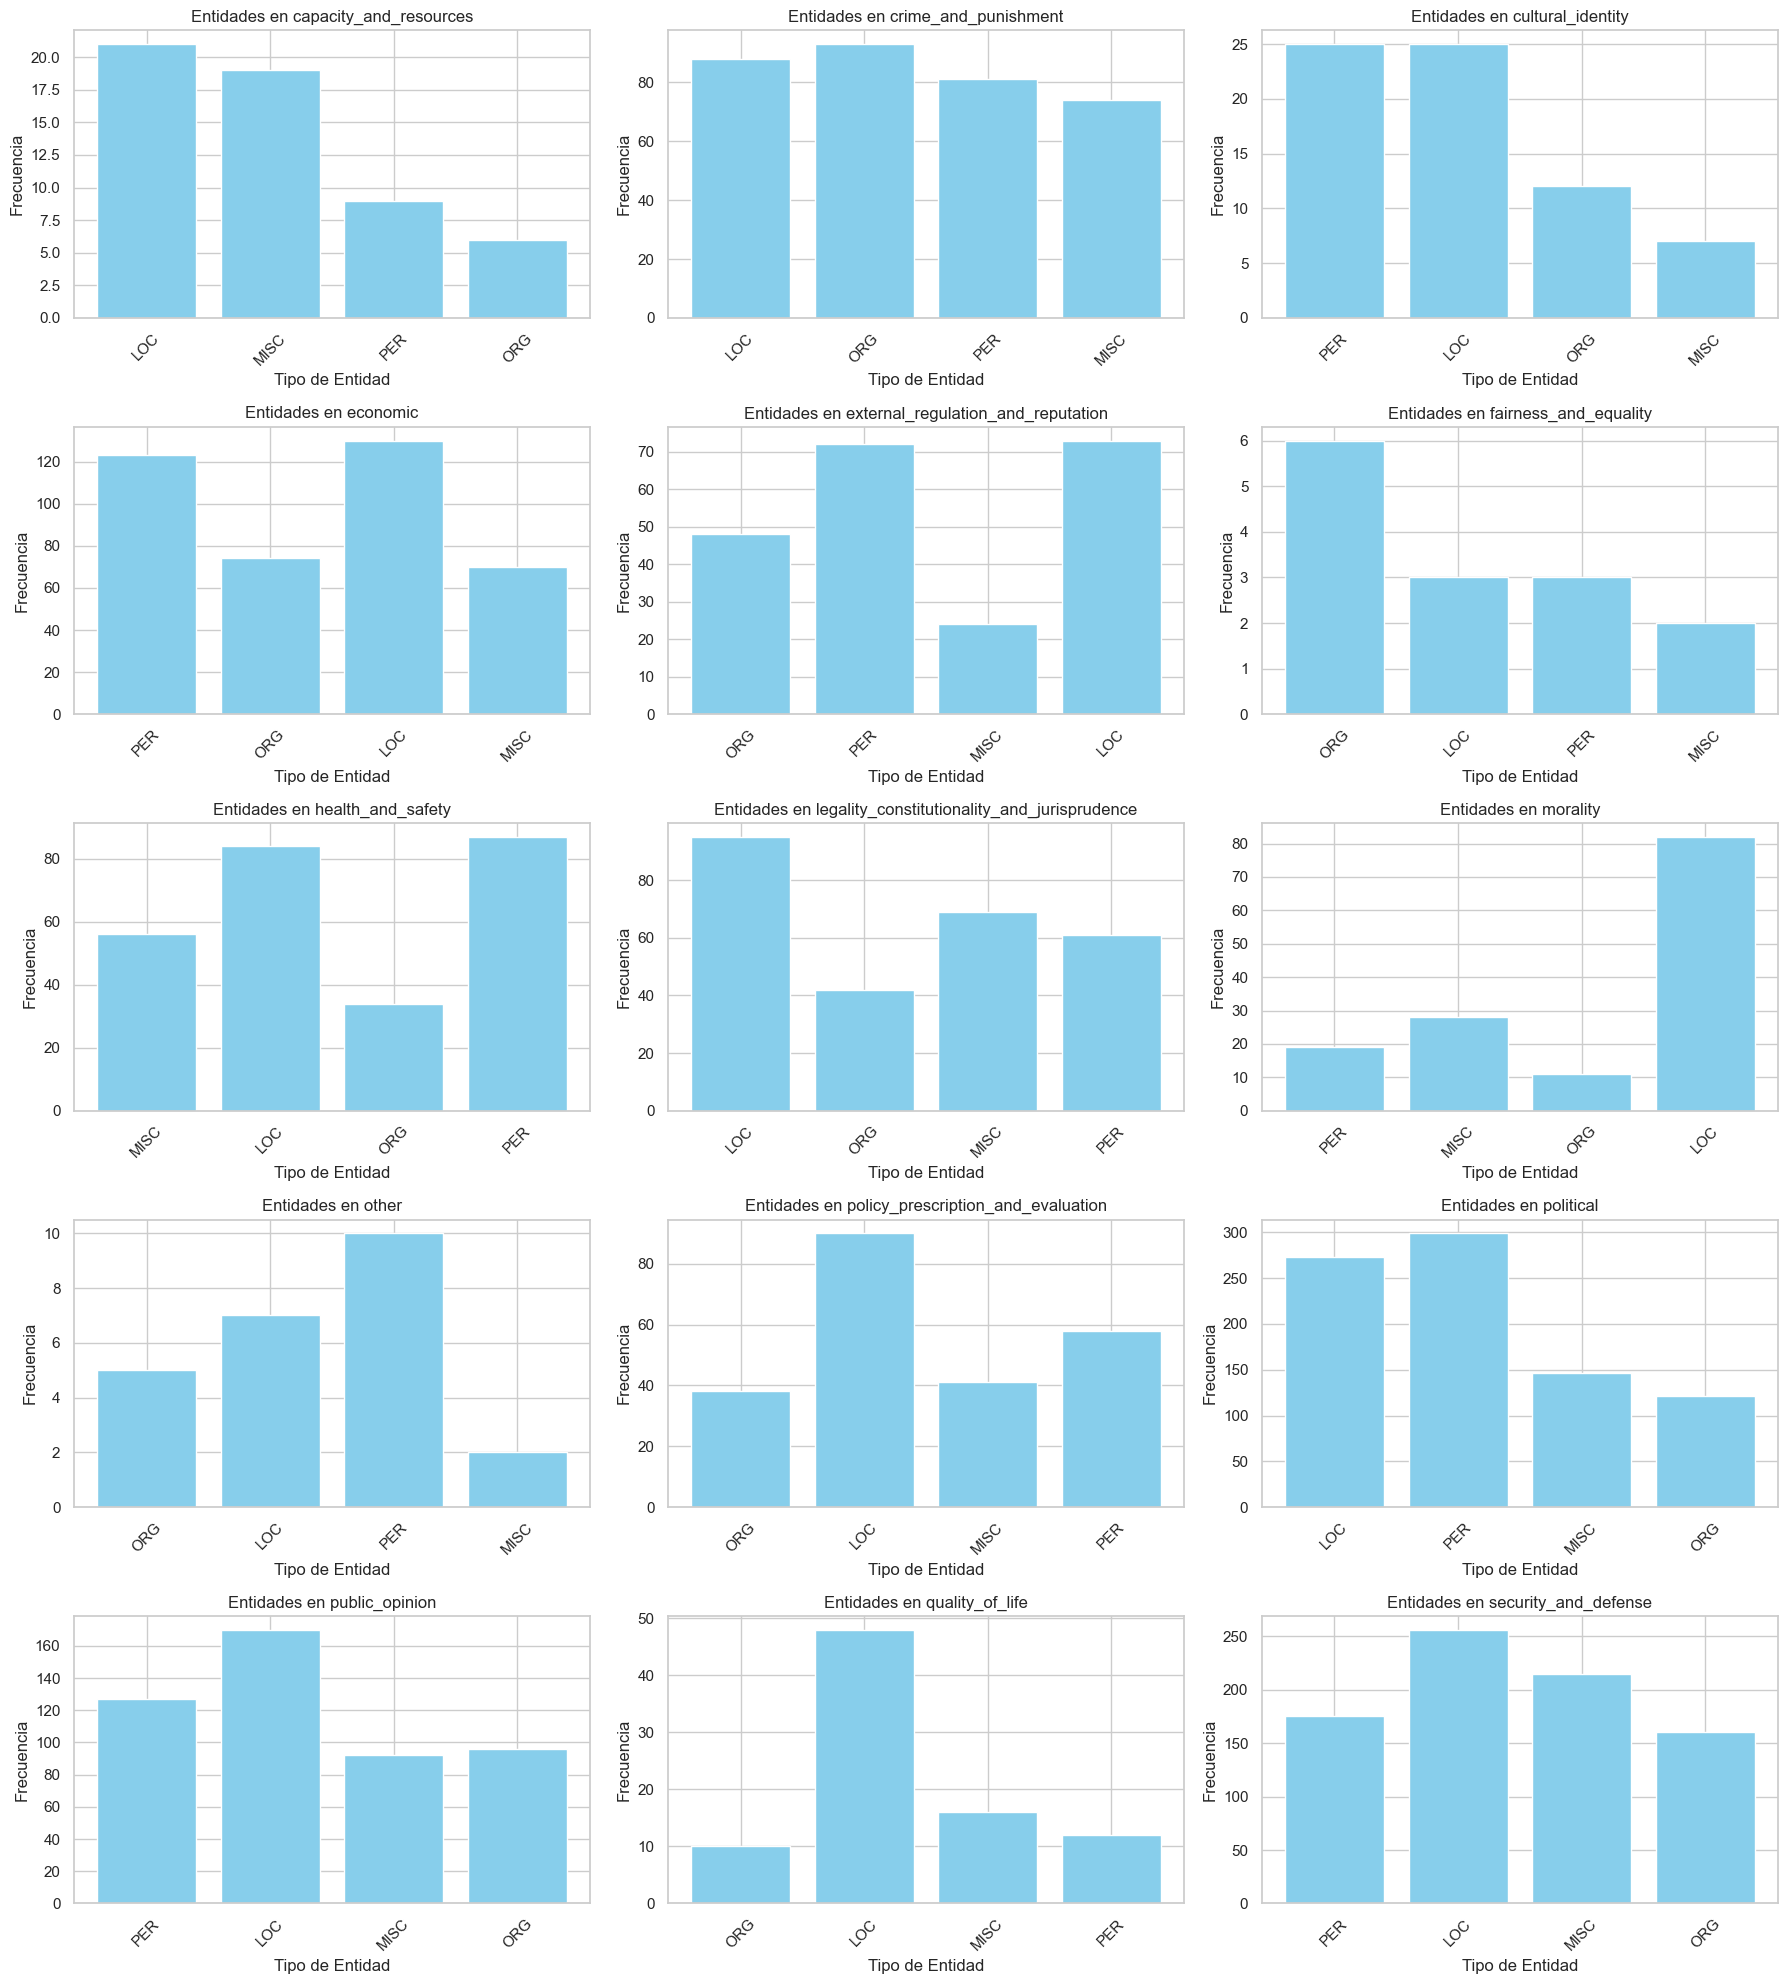

In [61]:
# Determine grid size
n = len(frame_texts_raw)
cols = 3  # You can change this to fit more/less per row
rows = math.ceil(n / cols)

fig, axs = plt.subplots(rows, cols, figsize=(cols*6, rows*4))
axs = axs.flatten()  # Flatten in case we have multiple rows

for idx, (frame, frame_text_cleaned_2) in enumerate(frame_texts_raw.items()):
    doc_frame = nlp(frame_text_cleaned_2)
    frame_entities = [ent.label_ for ent in doc_frame.ents]
    frame_entity_counts = Counter(frame_entities)

    ax = axs[idx]
    ax.bar(frame_entity_counts.keys(), frame_entity_counts.values(), color='skyblue')
    ax.set_xlabel("Tipo de Entidad")
    ax.set_ylabel("Frecuencia")
    ax.set_title(f"Entidades en {frame}")
    ax.tick_params(axis='x', rotation=45)

# Hide any unused subplots
for i in range(idx + 1, len(axs)):
    fig.delaxes(axs[i])

plt.tight_layout()
plt.show()


#### Paso 5.5.3: Nube de Palabras NER en general

In [62]:
# WordCloud for Named Entities
entity_text = " ".join([ent.text for ent in doc.ents])
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(entity_text)

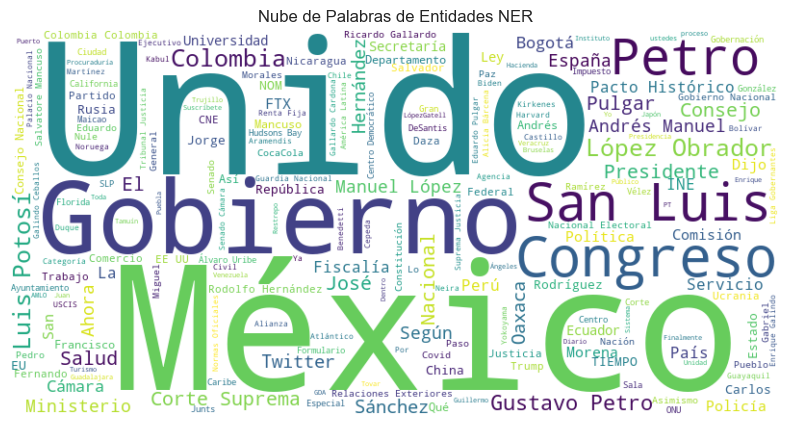

In [63]:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de Palabras de Entidades NER")
plt.show()

#### Paso 5.5.4: Nube de Palabras NER por tema

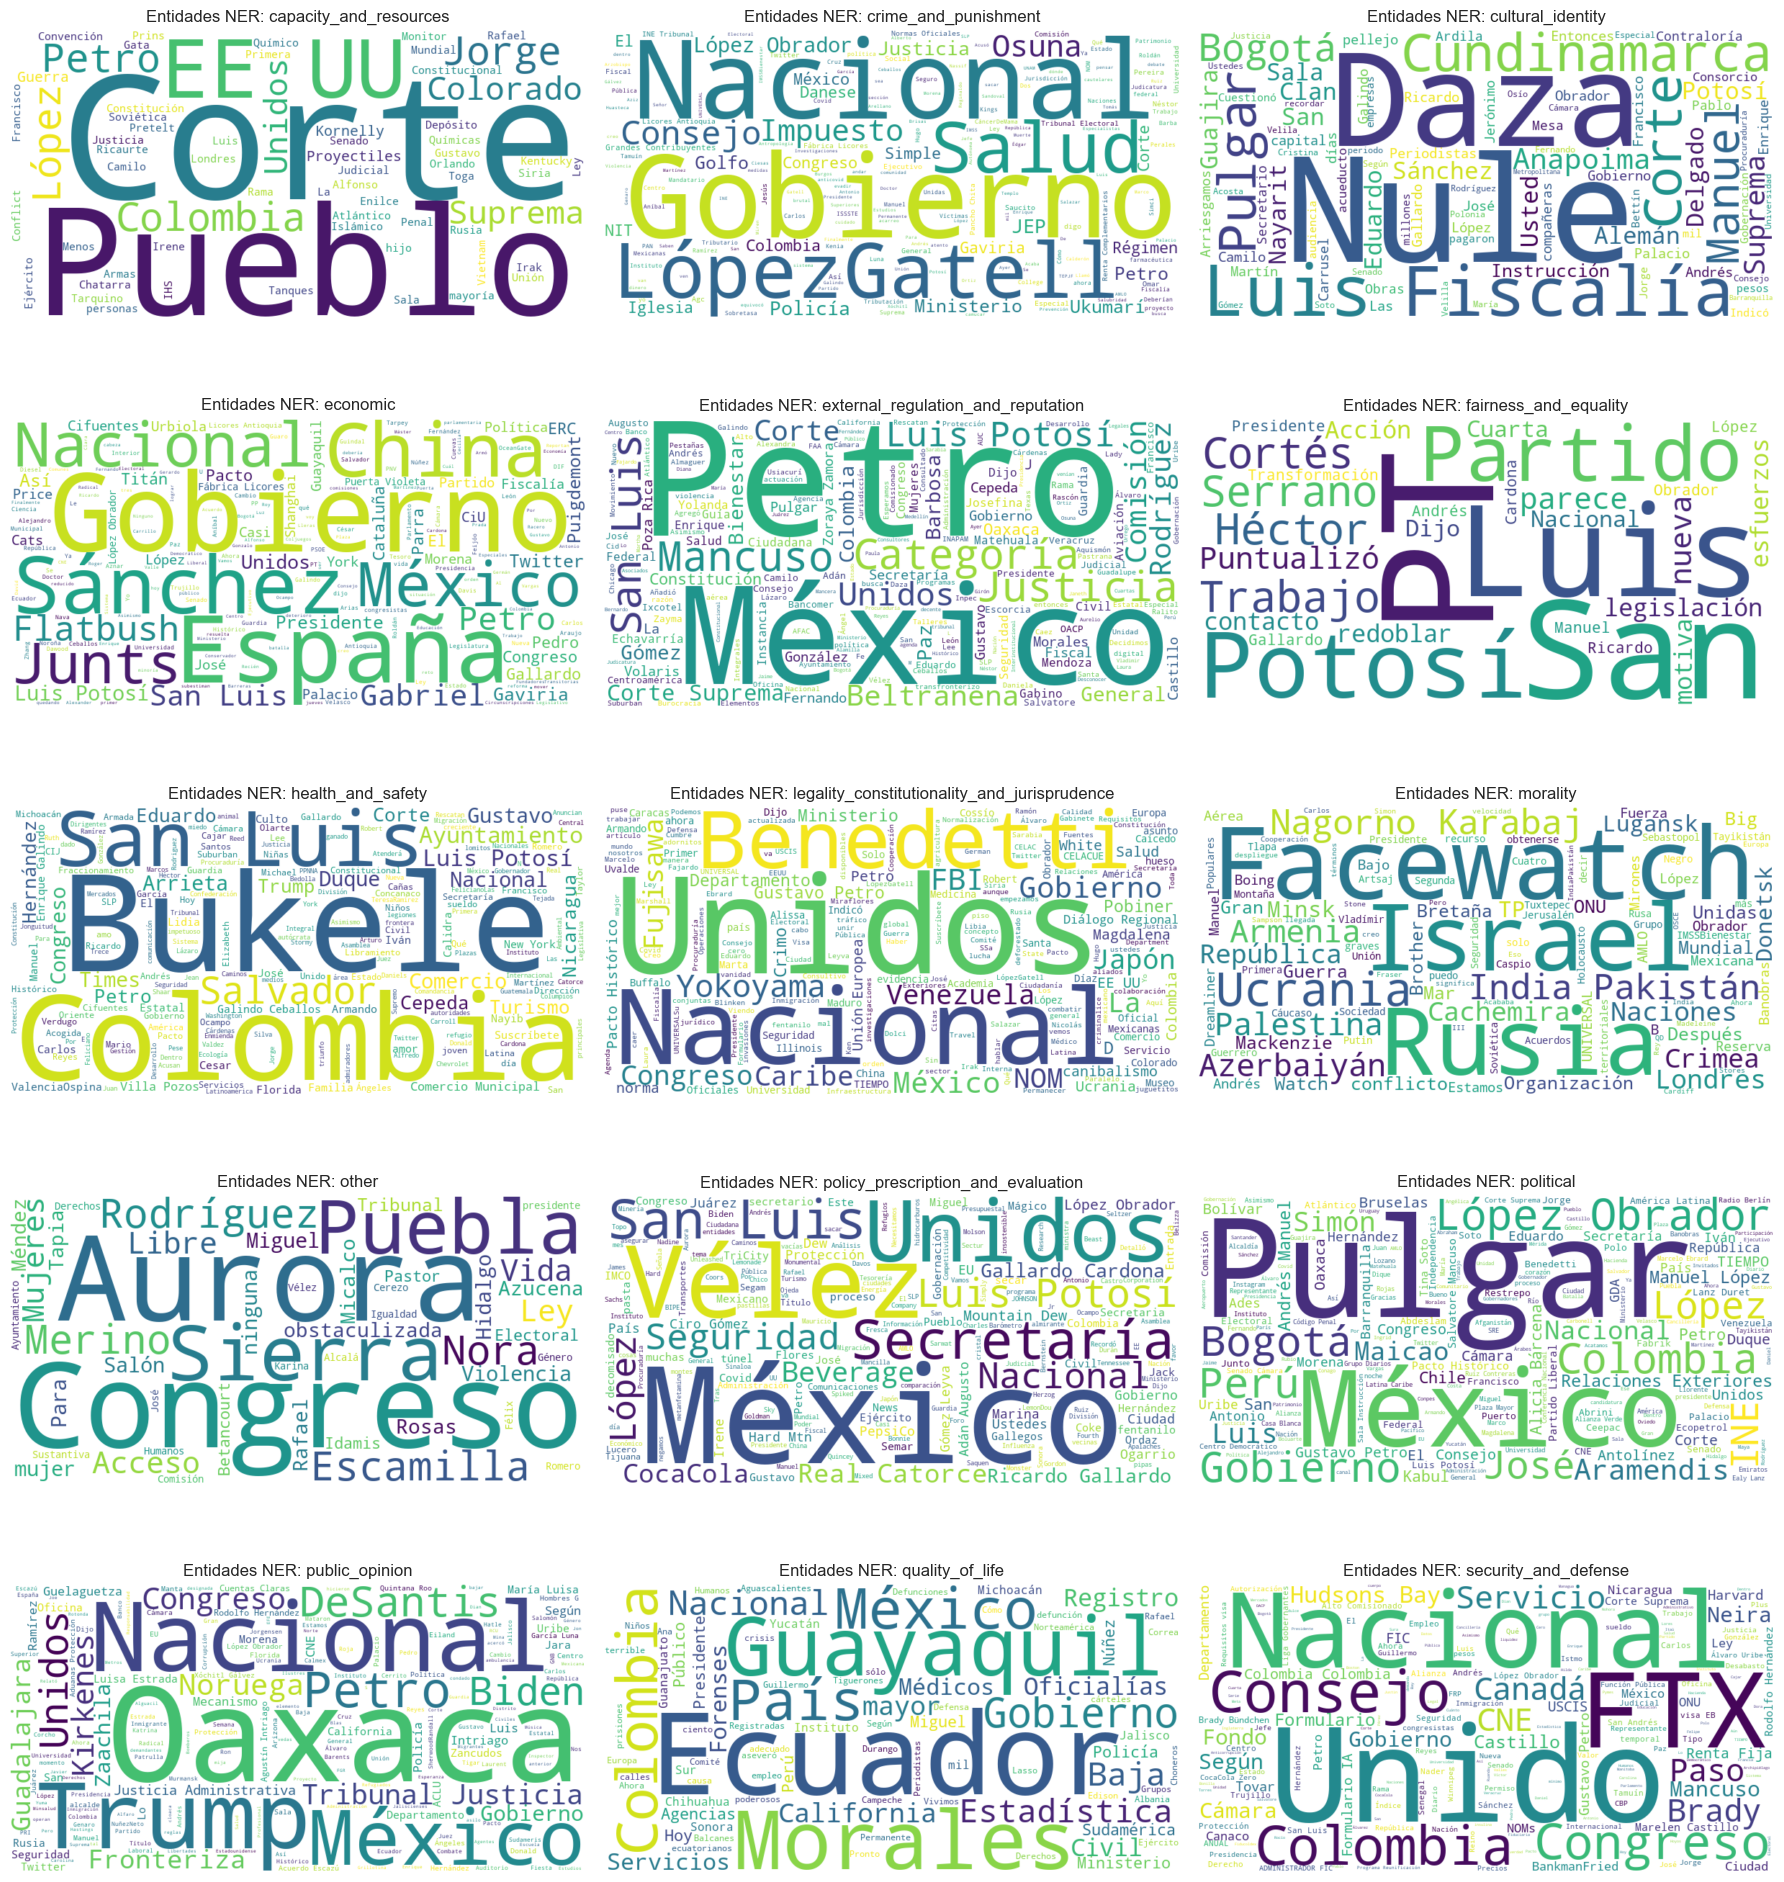

In [64]:
# Get total frames to determine grid size
num_frames = len(frame_texts_cleaned)
cols = 3  # You can change this
rows = -(-num_frames // cols)  # Ceiling division for rows

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4))
axes = axes.flatten()

# Loop over each frame and plot
for i, (frame, text) in enumerate(frame_texts_cleaned.items()):
    doc = nlp(text)
    entity_text = " ".join([ent.text for ent in doc.ents])
    wordcloud = WordCloud(width=800, height=400, background_color="white").generate(entity_text)

    axes[i].imshow(wordcloud, interpolation="bilinear")
    axes[i].axis("off")
    axes[i].set_title(f"Entidades NER: {frame}")

# Turn off any unused subplots
for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


### Paso 5.6: Visualización de Etiquetado de Partes del Discurso (POS)

#### Paso 5.6.1: Distribución general de POS Tags

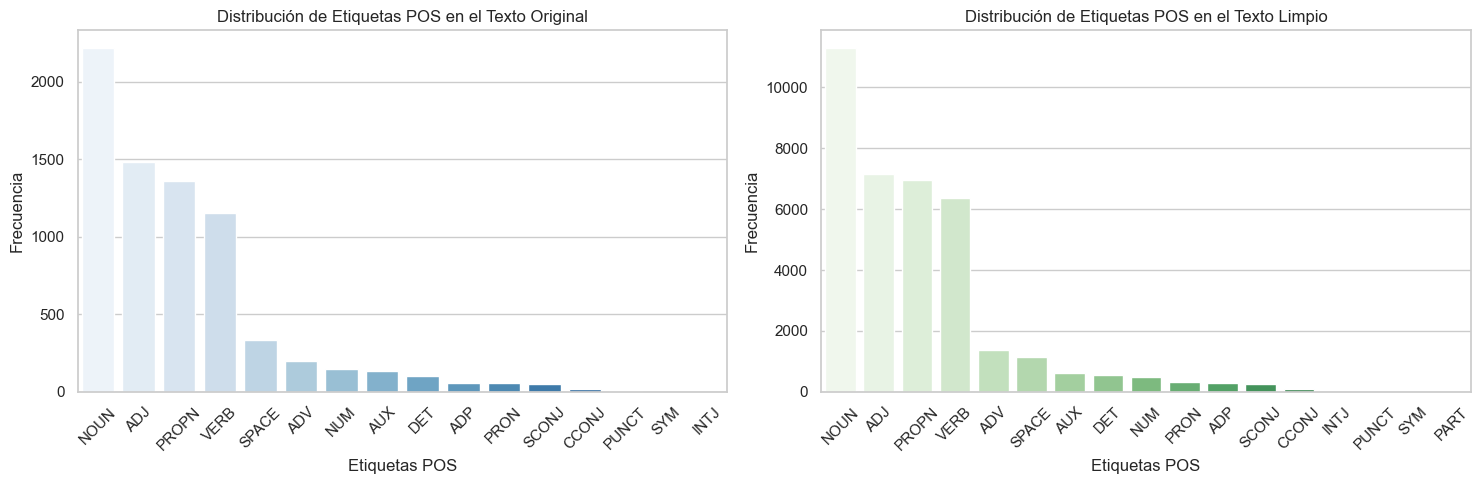

In [65]:
# Process both texts with SpaCy
doc_original = nlp(text)
doc_cleaned = nlp(text_cleaned)

# Extract POS tags
pos_tags_original = [token.pos_ for token in doc_original if not token.is_punct]  # Ignore punctuation
pos_tags_cleaned = [token.pos_ for token in doc_cleaned if not token.is_punct]  # Ignore punctuation

# Count POS tags
pos_counts_original = Counter(pos_tags_original)
pos_counts_cleaned = Counter(pos_tags_cleaned)

# Sort POS tags by frequency (high to low)
pos_sorted_original = sorted(pos_counts_original.items(), key=lambda x: x[1], reverse=True)
pos_sorted_cleaned = sorted(pos_counts_cleaned.items(), key=lambda x: x[1], reverse=True)

# Create a plot with two subplots for original and cleaned texts
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot for original text POS distribution
sns.barplot(x=[tag for tag, _ in pos_sorted_original], y=[count for _, count in pos_sorted_original], ax=axes[0], hue=[tag for tag, _ in pos_sorted_original], palette="Blues", legend=False)
axes[0].set_title("Distribución de Etiquetas POS en el Texto Original")
axes[0].set_xlabel("Etiquetas POS")
axes[0].set_ylabel("Frecuencia")
axes[0].tick_params(axis='x', rotation=45)

# Plot for cleaned text POS distribution
sns.barplot(x=[tag for tag, _ in pos_sorted_cleaned], y=[count for _, count in pos_sorted_cleaned], ax=axes[1], hue=[tag for tag, _ in pos_sorted_cleaned], palette="Greens", legend=False)
axes[1].set_title("Distribución de Etiquetas POS en el Texto Limpio")
axes[1].set_xlabel("Etiquetas POS")
axes[1].set_ylabel("Frecuencia")
axes[1].tick_params(axis='x', rotation=45)

# Show the plots
plt.tight_layout()
plt.show()

#### Paso 5.6.2: Distribución por tema de POS Tags

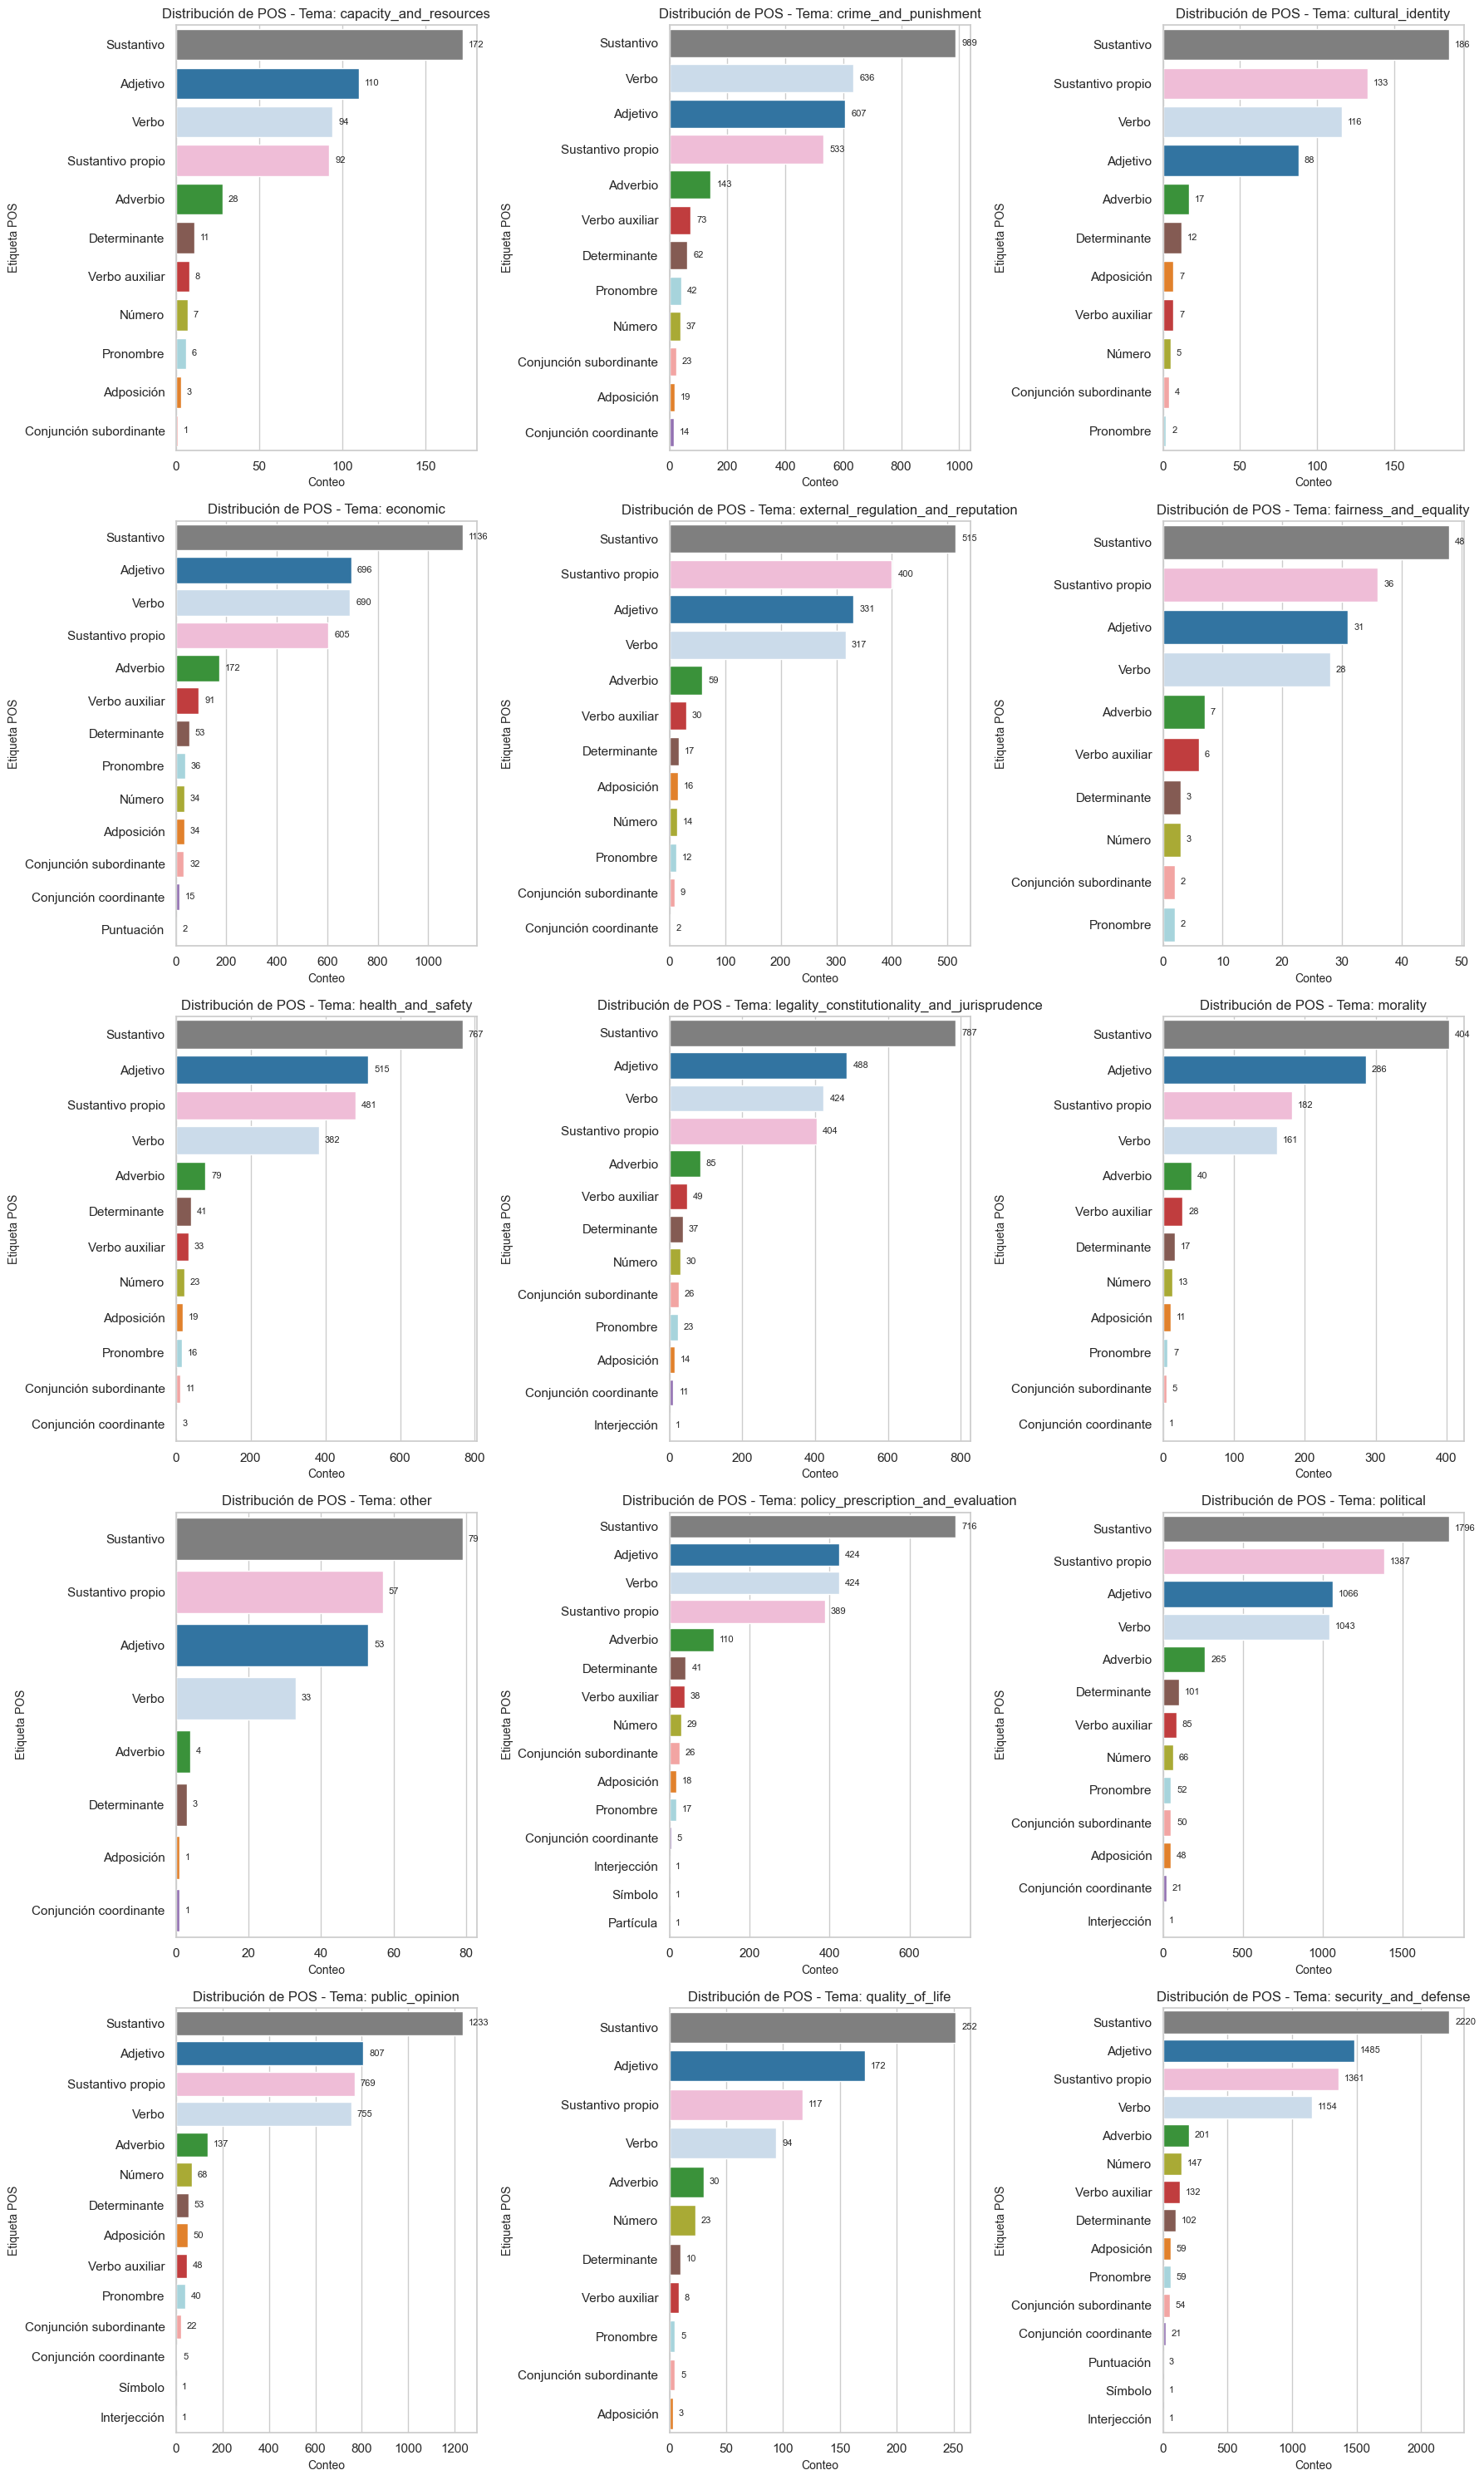

In [66]:
#### Paso 5.6.1: Distribución por tema de POS Tags (en español con colores consistentes)
frame_pos_data = {}

# Spanish translation for POS tags
pos_translation = {
    "ADJ": "Adjetivo",
    "ADP": "Adposición",
    "ADV": "Adverbio",
    "AUX": "Verbo auxiliar",
    "CCONJ": "Conjunción coordinante",
    "DET": "Determinante",
    "INTJ": "Interjección",
    "NOUN": "Sustantivo",
    "NUM": "Número",
    "PART": "Partícula",
    "PRON": "Pronombre",
    "PROPN": "Sustantivo propio",
    "PUNCT": "Puntuación",
    "SCONJ": "Conjunción subordinante",
    "SYM": "Símbolo",
    "VERB": "Verbo",
    "X": "Otro"
}

# Assign a consistent color for each POS tag
pos_colors = {
    "Adjetivo": "#1f77b4",  # Blue
    "Adposición": "#ff7f0e",  # Orange
    "Adverbio": "#2ca02c",  # Green
    "Verbo auxiliar": "#d62728",  # Red
    "Conjunción coordinante": "#9467bd",  # Purple
    "Determinante": "#8c564b",  # Brown
    "Interjección": "#e377c2",  # Pink
    "Sustantivo": "#7f7f7f",  # Gray
    "Número": "#bcbd22",  # Yellow-green
    "Partícula": "#17becf",  # Cyan
    "Pronombre": "#9edae5",  # Light cyan
    "Sustantivo propio": "#f7b5d7",  # Light pink
    "Puntuación": "#c2c2c2",  # Light gray
    "Conjunción subordinante": "#ff9896",  # Light red
    "Símbolo": "#98df8a",  # Light green
    "Verbo": "#c6dbef",  # Light blue
    "Otro": "#ffcc99"  # Light orange
}

# Iterate through the cleaned text for each frame
for frame, cleaned_text in frame_texts_cleaned.items():
    doc = nlp(cleaned_text)  # Process the cleaned text

    pos_tags = [token.pos_ for token in doc if not token.is_punct and not token.is_space]

    if frame not in frame_pos_data:
        frame_pos_data[frame] = []
    frame_pos_data[frame].extend(pos_tags)

# Determine the layout
num_frames = len(frame_pos_data)
cols = 3
rows = (num_frames + cols - 1) // cols

# Create figure with adjusted size and spacing
fig, axes = plt.subplots(rows, cols, figsize=(18, 6 * rows))  # Reduce width and height for a more compact layout
fig.subplots_adjust(wspace=0.2, hspace=0.4)  # Decrease the space between plots

# Flatten axes
axes = axes.flatten()

for i, (frame, tags) in enumerate(frame_pos_data.items()):
    # Translate POS tags into Spanish
    translated_tags = [pos_translation.get(tag, tag) for tag in tags]  # Use the Spanish translation if available

    pos_counts = Counter(translated_tags)
    pos_df = pd.DataFrame(sorted(pos_counts.items(), key=lambda x: x[1], reverse=True),
                          columns=['POS_Tag', 'Count'])

    # Limit to top N tags
    top_n = 15
    pos_df = pos_df.head(top_n)

    ax = axes[i]

    # Horizontal bar plot with custom color palette
    sns.barplot(data=pos_df, y='POS_Tag', x='Count', hue='POS_Tag',
                palette={tag: pos_colors[tag] for tag in pos_df['POS_Tag']}, legend=False, ax=ax)
    ax.set_title(f"Distribución de POS - Tema: {frame}",
                 fontsize=12)  # Adjust title font size for better space management
    ax.set_xlabel("Conteo", fontsize=10)
    ax.set_ylabel("Etiqueta POS", fontsize=10)

    # Add value labels
    for p in ax.patches:
        width = p.get_width()
        ax.annotate(f'{width:.0f}',
                    (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center',
                    xytext=(5, 0),
                    textcoords='offset points',
                    fontsize=8)  # Reduce font size for value labels

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()  # Adjust everything to fit more compactly
plt.show()

#### Paso 5.6.3: Red de POS Tags

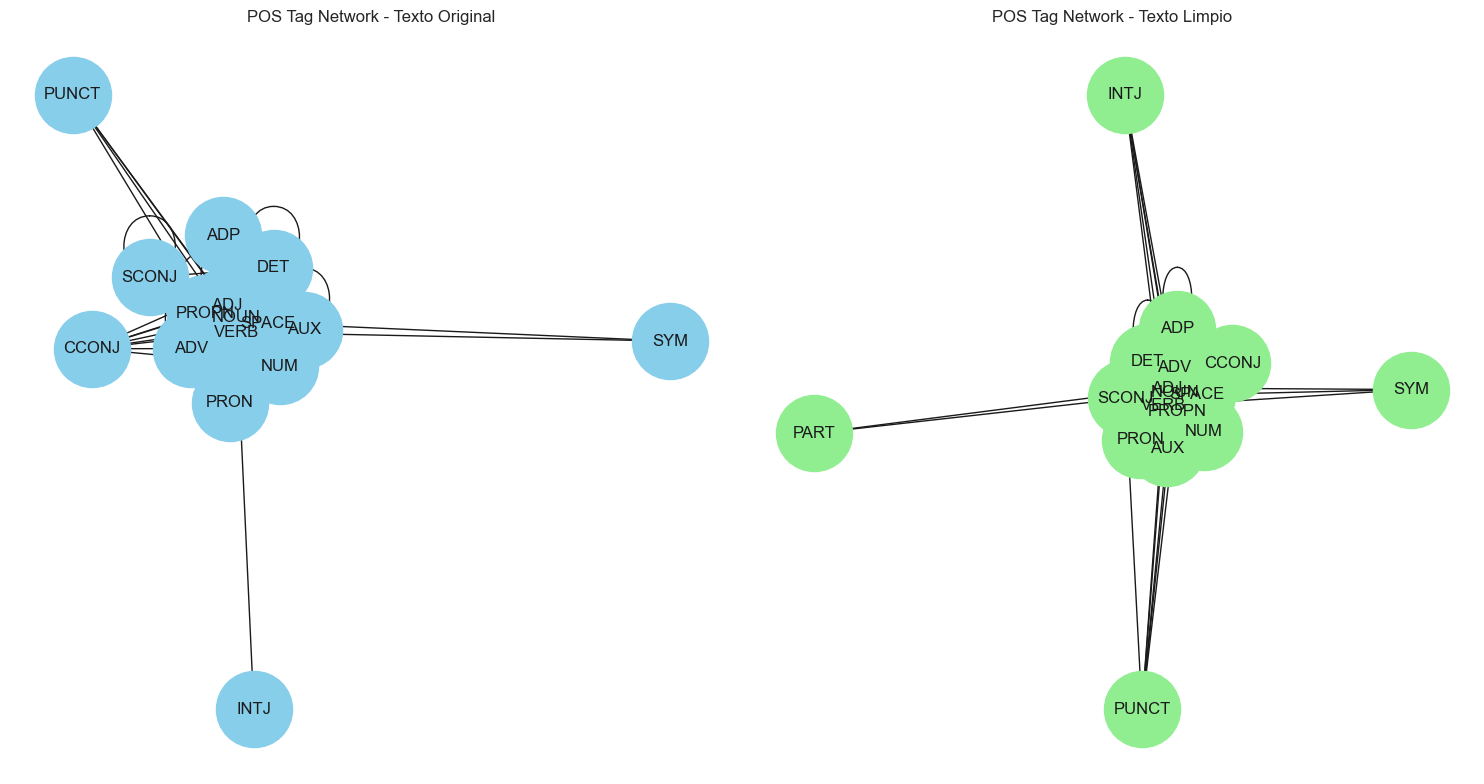

In [67]:
# Process both texts with SpaCy
doc_original = nlp(text)
doc_cleaned = nlp(text_cleaned)

# Extract POS tags
pos_tags_original = [token.pos_ for token in doc_original if not token.is_punct]  # Ignore punctuation
pos_tags_cleaned = [token.pos_ for token in doc_cleaned if not token.is_punct]  # Ignore punctuation

# Count POS tags
pos_counts_original = Counter(pos_tags_original)
pos_counts_cleaned = Counter(pos_tags_cleaned)

# Sort POS tags by frequency (high to low)
pos_sorted_original = sorted(pos_counts_original.items(), key=lambda x: x[1], reverse=True)
pos_sorted_cleaned = sorted(pos_counts_cleaned.items(), key=lambda x: x[1], reverse=True)

# Function to create POS Tag Network
def create_pos_tag_network(pos_tags):
    G = nx.Graph()

    # Add nodes and edges to the graph based on POS tag co-occurrence
    for i in range(len(pos_tags) - 1):
        pos1, pos2 = pos_tags[i], pos_tags[i + 1]
        if G.has_edge(pos1, pos2):
            G[pos1][pos2]['weight'] += 1
        else:
            G.add_edge(pos1, pos2, weight=1)

    return G

# Create POS Tag Networks for both original and cleaned texts
pos_network_original = create_pos_tag_network(pos_tags_original)
pos_network_cleaned = create_pos_tag_network(pos_tags_cleaned)

# Plotting POS Tag Networks
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# Original Text Network Plot
pos_labels_original = {node: node for node in pos_network_original.nodes()}
pos_pos_original = nx.spring_layout(pos_network_original)
nx.draw(pos_network_original, pos=pos_pos_original, with_labels=True, ax=axes[0], node_size=3000, node_color='skyblue', font_size=12)
axes[0].set_title("POS Tag Network - Texto Original")

# Cleaned Text Network Plot
pos_labels_cleaned = {node: node for node in pos_network_cleaned.nodes()}
pos_pos_cleaned = nx.spring_layout(pos_network_cleaned)
nx.draw(pos_network_cleaned, pos=pos_pos_cleaned, with_labels=True, ax=axes[1], node_size=3000, node_color='lightgreen', font_size=12)
axes[1].set_title("POS Tag Network - Texto Limpio")

plt.tight_layout()
plt.show()

#### Paso 5.6.4: POS Tag Transition Matrix

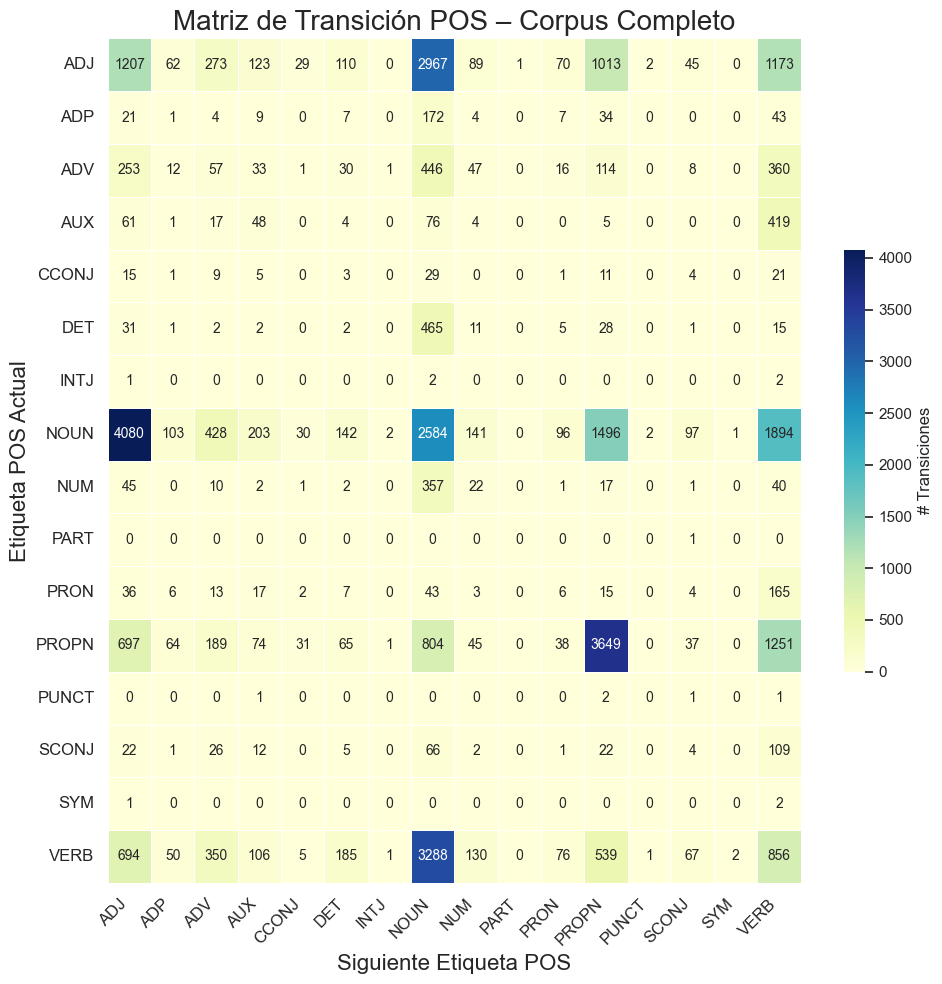

In [68]:
# 3. Obtener la secuencia de POS tags
doc = nlp(text_cleaned)
pos_tags = [token.pos_ for token in doc if not token.is_punct and not token.is_space]

# 4. Contar transiciones
transition_counts = defaultdict(lambda: defaultdict(int))
for i in range(len(pos_tags) - 1):
    curr, nxt = pos_tags[i], pos_tags[i+1]
    transition_counts[curr][nxt] += 1

# 5. Crear DataFrame de la matriz
all_tags = sorted(set(transition_counts.keys()) | {t for d in transition_counts.values() for t in d})
mat = pd.DataFrame(0, index=all_tags, columns=all_tags)
for frm, to_dict in transition_counts.items():
    for to, cnt in to_dict.items():
        mat.loc[frm, to] = cnt

# 6. Dibujar heatmap con mejor visibilidad
plt.figure(figsize=(10, 10))  # Más grande
sns.heatmap(
    mat,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    linewidths=0.5,
    annot_kws={"fontsize": 10},  # más grande
    cbar_kws={"shrink": 0.5, "label": "# Transiciones"}
)

plt.title("Matriz de Transición POS – Corpus Completo", fontsize=20)
plt.xlabel("Siguiente Etiqueta POS", fontsize=16)
plt.ylabel("Etiqueta POS Actual", fontsize=16)
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()
plt.show()


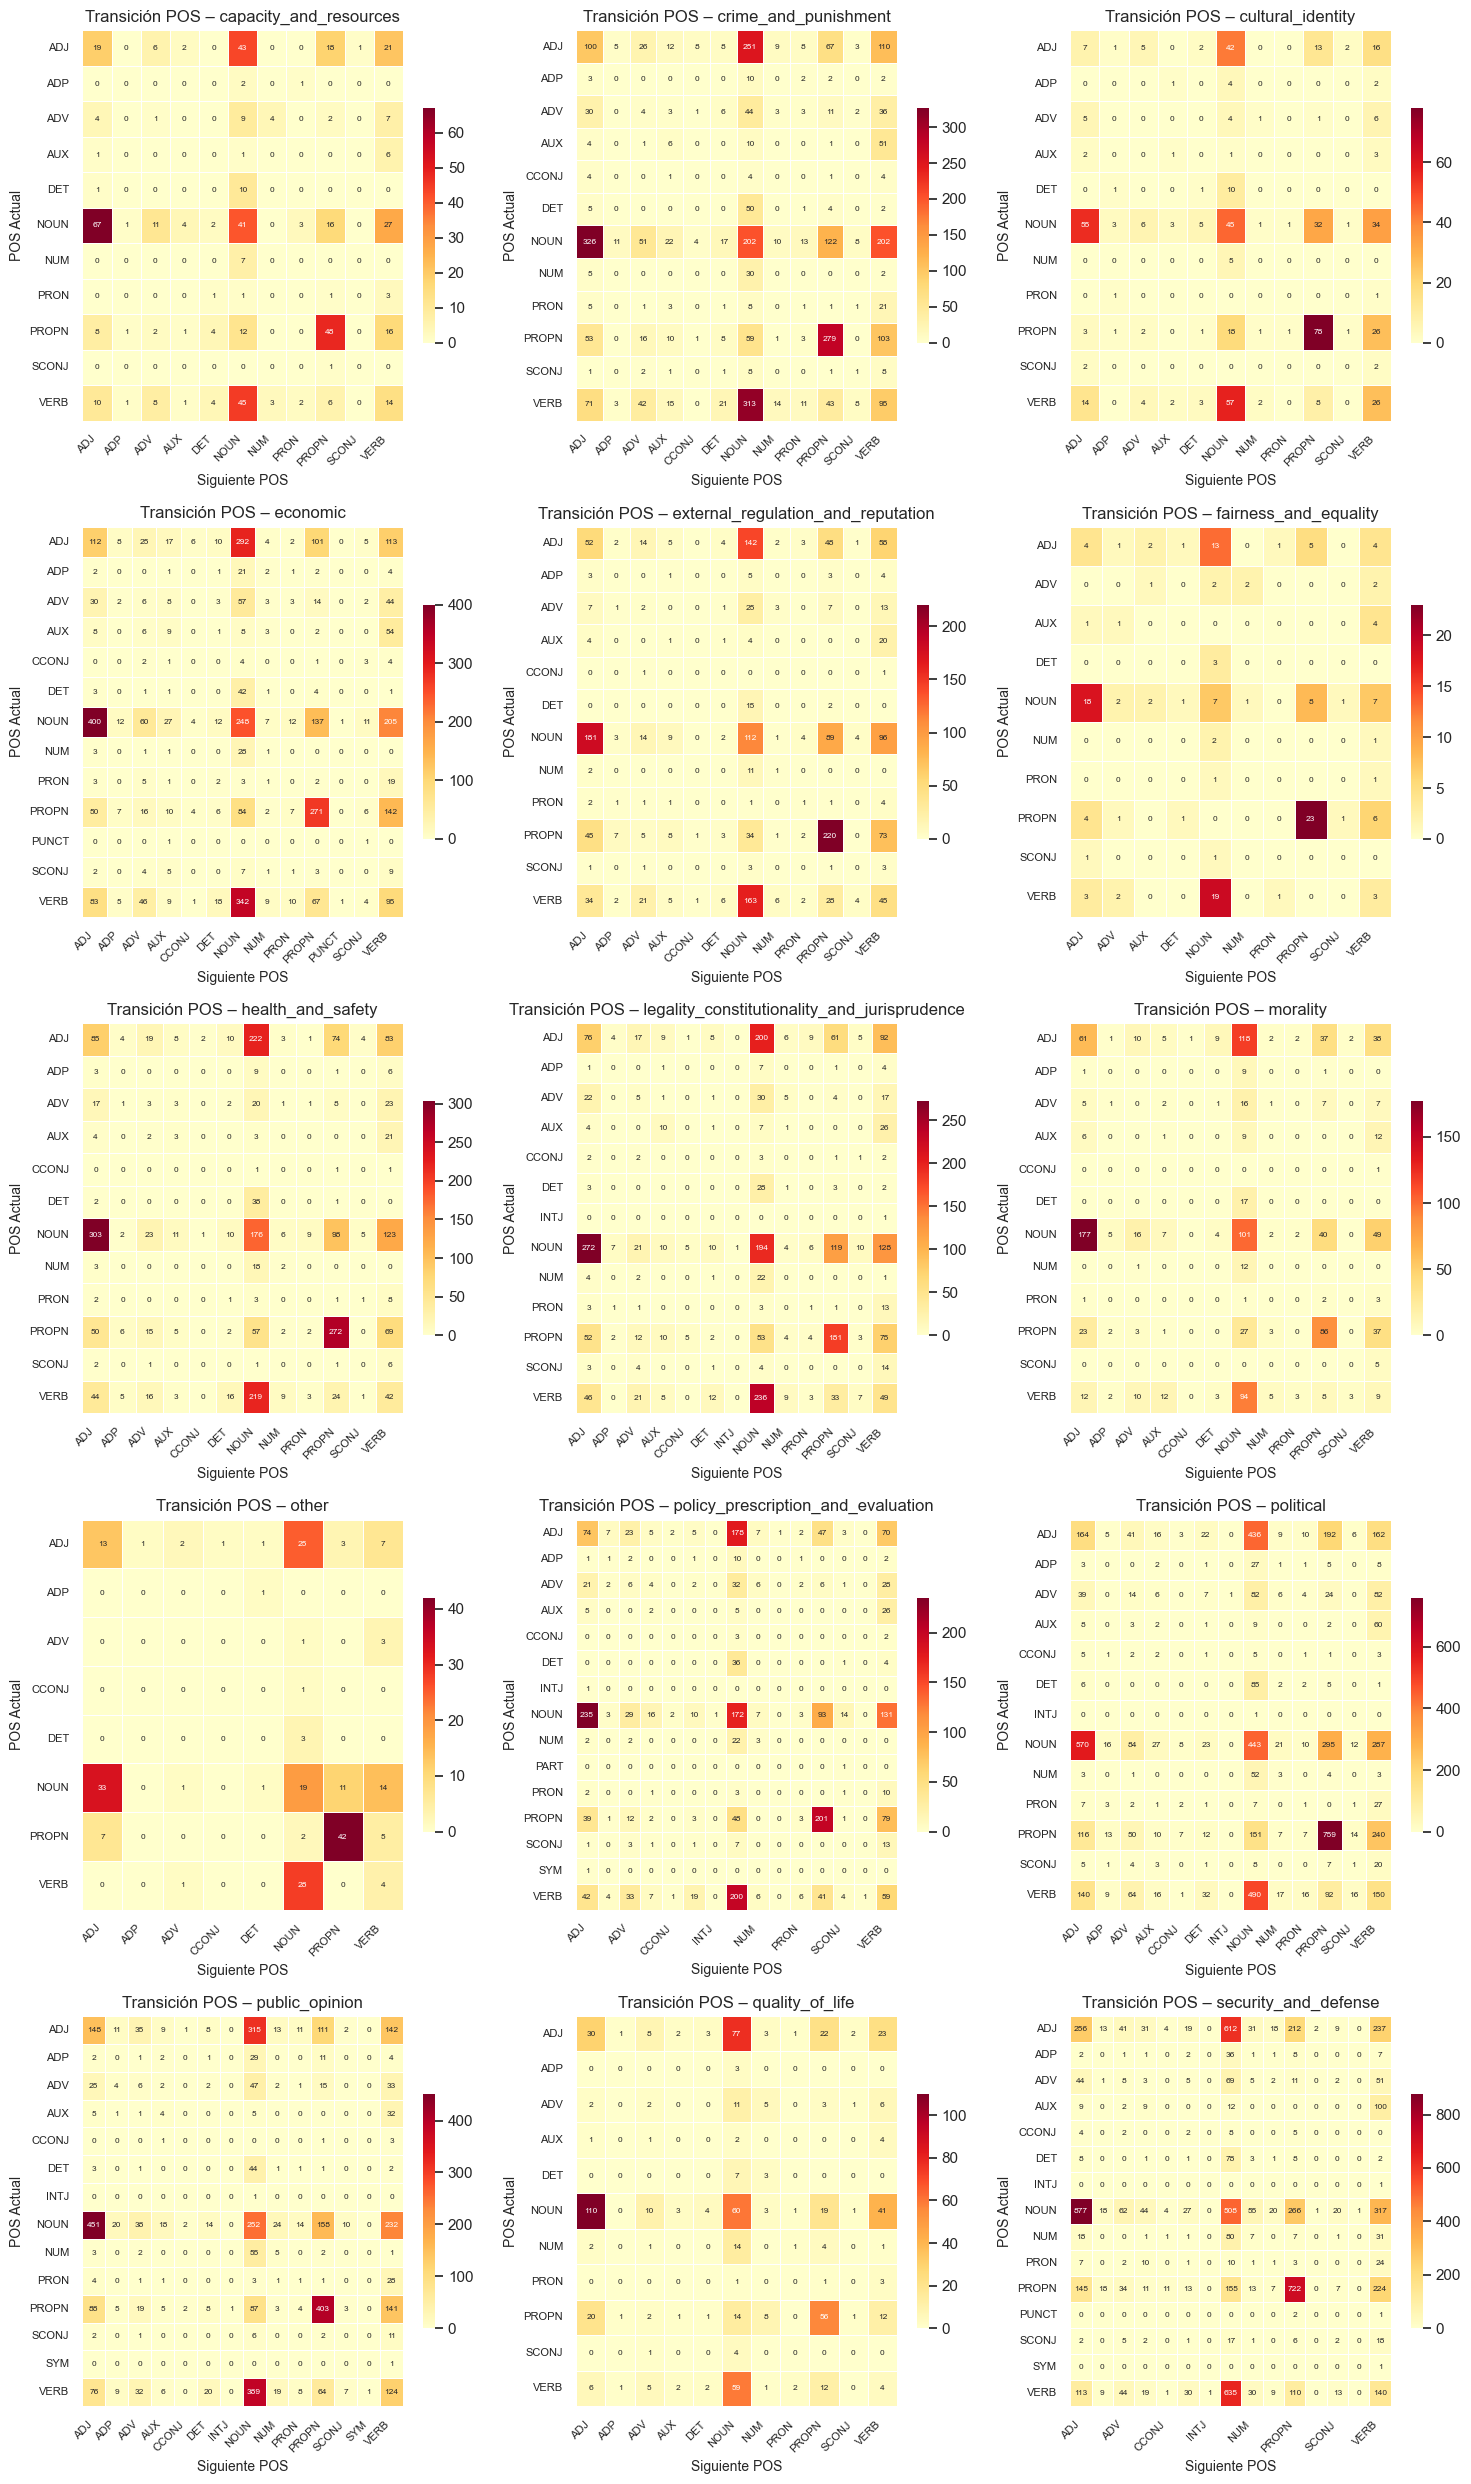

In [69]:
num_frames = len(frame_texts_cleaned)
cols = 3
rows = (num_frames + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
plt.subplots_adjust(wspace=0.5, hspace=0.6)

axes = axes.flatten()
for idx, (frame, text) in enumerate(frame_texts_cleaned.items()):
    # POS transitions
    doc = nlp(text)
    tags = [t.pos_ for t in doc if not t.is_punct and not t.is_space]
    tc = defaultdict(lambda: defaultdict(int))
    for i in range(len(tags)-1):
        tc[tags[i]][tags[i+1]] += 1

    # Build matrix
    all_tags = sorted(set(t for d in tc.values() for t in d) | set(tc.keys()))
    df_mat = pd.DataFrame(0, index=all_tags, columns=all_tags)
    for frm, to_d in tc.items():
        for to, c in to_d.items():
            df_mat.loc[frm, to] = c

    # Plot
    ax = axes[idx]
    sns.heatmap(
        df_mat,
        annot=True,
        fmt="d",
        cmap="YlOrRd",
        linewidths=0.5,
        ax=ax,
        annot_kws={"fontsize": 6},       # smaller annotation font
        cbar_kws={"shrink": 0.6}          # smaller colorbar
    )
    ax.set_title(f"Transición POS – {frame}", fontsize=12)
    ax.set_xlabel("Siguiente POS", fontsize=10)
    ax.set_ylabel("POS Actual", fontsize=10)

    # Ticks
    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=45,
        ha="right",
        fontsize=8
    )
    ax.set_yticklabels(
        ax.get_yticklabels(),
        rotation=0,
        fontsize=8
    )

# Hide any unused subplots
for j in range(idx+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

### Paso 5.7: Visualizaciones de Modelado de Temas

#### Paso 5.7.1: Distribución de los Temas

In [70]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [71]:
def preprocess_text(text):
    words = nltk.word_tokenize(text.lower())  # Tokenize and convert to lowercase
    return ' '.join([word for word in words if word.isalnum() and word not in spanish_stopwords])

df['processed_news'] = df['news'].apply(preprocess_text)

# Convert text into a document-term matrix using CountVectorizer
vectorizer = CountVectorizer()
doc_term_matrix = vectorizer.fit_transform(df['processed_news'])

# Train LDA model
num_topics = 5
lda_model = LatentDirichletAllocation(n_components=num_topics, random_state=42)
lda_model.fit(doc_term_matrix)

# Display extracted topics
feature_names = vectorizer.get_feature_names_out()
print("\nExtracted Topics:")
for topic_idx, topic in enumerate(lda_model.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-6:-1]]
    print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")

# Assign topic distribution for each document
doc_topic_distribution = lda_model.transform(doc_term_matrix)

print("\nTopic Distribution per Document:")
df['topic_distribution'] = list(doc_topic_distribution)
print(df[['news', 'topic_distribution']])


Extracted Topics:
Topic 1: ciento, dijo, gobierno, migrantes, méxico
Topic 2: gobierno, paz, proceso, consejo, pesos
Topic 3: mil, presidente, gobierno, nacional, lópez
Topic 4: presidente, dos, gobierno, pulgar, años
Topic 5: personas, ftx, millones, gatos, san

Topic Distribution per Document:
                                                  news  \
0    ¿Cuánto tiempo estoy autorizado a permanecer e...   
1    Colombia y Venezuela instalaron comisión de ve...   
2    Atrasar proceso electoral hasta enero de 2024,...   
3    Avanza SLP en cuanto a transparencia presupues...   
4    Confía dirigente del PT en mantener el registr...   
..                                                 ...   
135  Vacaciones de terror: agencia de viajes poblan...   
136  En SLP, la gasolina más barata se vende por de...   
137  Inflación baja a 4.79% en la primera mitad de ...   
138  Reducción de jornada laboral provocará un desp...   
139  Advierte Ricardo Gallardo más cambios en su ga...   

     

#### Paso 5.7.2: Asociaciones entre Temas y Palabras

In [72]:
df.head()

,id,news,frames,tone,principal_frames,economic,capacity_and_resources,morality,fairness_and_equality,legality_constitutionality_and_jurisprudence,...,character_count,sentence_count,average_word_length,word_tokens,sentence_tokens,text_length,bigramas,trigrams,processed_news,topic_distribution
0,Noticia_1.txt,¿Cuánto tiempo estoy autorizado a permanecer e...,"['external_regulation_and_reputation', 'legali...",neutral,legality_constitutionality_and_jurisprudence,0,0,0,0,1,...,3148.0,25.0,4.976562,"[¿cuánto, tiempo, estoy, autorizado, a, perman...",[¿Cuánto tiempo estoy autorizado a permanecer ...,3148,"[(tiempo, autorizado), (autorizado, permanecer...","[(tiempo, autorizado, permanecer), (autorizado...",tiempo autorizado permanecer unidos crucial te...,"[0.9967922807070877, 0.0008002306288073294, 0...."
1,Noticia_2.txt,Colombia y Venezuela instalaron comisión de ve...,"['policy_prescription_and_evaluation', 'politi...",neutral,political,1,0,1,0,0,...,2661.0,16.0,5.210402,"[colombia, y, venezuela, instalaron, comisión,...",[Colombia y Venezuela instalaron comisión de v...,2661,"[(colombia, venezuela), (venezuela, instalaron...","[(colombia, venezuela, instalaron), (venezuela...",colombia venezuela instalaron comisión vecinda...,"[0.000927199943929397, 0.9963158496131805, 0.0..."
2,Noticia_7.txt,"Atrasar proceso electoral hasta enero de 2024,...","['political', 'quality_of_life', 'public_opini...",neutral,political,0,0,0,0,0,...,2023.0,5.0,5.395570,"[atrasar, proceso, electoral, hasta, enero, de...",[Atrasar proceso electoral hasta enero de 2024...,2023,"[(atrasar, proceso), (proceso, electoral), (el...","[(atrasar, proceso, electoral), (proceso, elec...",atrasar proceso electoral enero 2024 puesto de...,"[0.0012145395989369514, 0.0012229648012087794,..."
3,Noticia_8.txt,Avanza SLP en cuanto a transparencia presupues...,"['policy_prescription_and_evaluation', 'public...",neutral,policy_prescription_and_evaluation,0,0,0,0,0,...,1934.0,7.0,4.713018,"[avanza, slp, en, cuanto, a, transparencia, pr...",[Avanza SLP en cuanto a transparencia presupue...,1934,"[(avanza, slp), (slp, cuanto), (cuanto, transp...","[(avanza, slp, cuanto), (slp, cuanto, transpar...",avanza slp cuanto transparencia presupuestal 2...,"[0.0011425075753714858, 0.001140399494062386, ..."
4,Noticia_9.txt,Confía dirigente del PT en mantener el registr...,"['external_regulation_and_reputation', 'qualit...",negative,fairness_and_equality,0,1,0,1,0,...,1890.0,4.0,4.848297,"[confía, dirigente, del, pt, en, mantener, el,...",[Confía dirigente del PT en mantener el regist...,1890,"[(confía, dirigente), (dirigente, pt), (pt, ma...","[(confía, dirigente, pt), (dirigente, pt, mant...",confía dirigente pt mantener registro san luis...,"[0.001252846774181039, 0.0012512176397002695, ..."


### Paso 5.8: Visualizaciones de los sesgos principales

In [73]:
order  = df["principal_frames"].value_counts().index

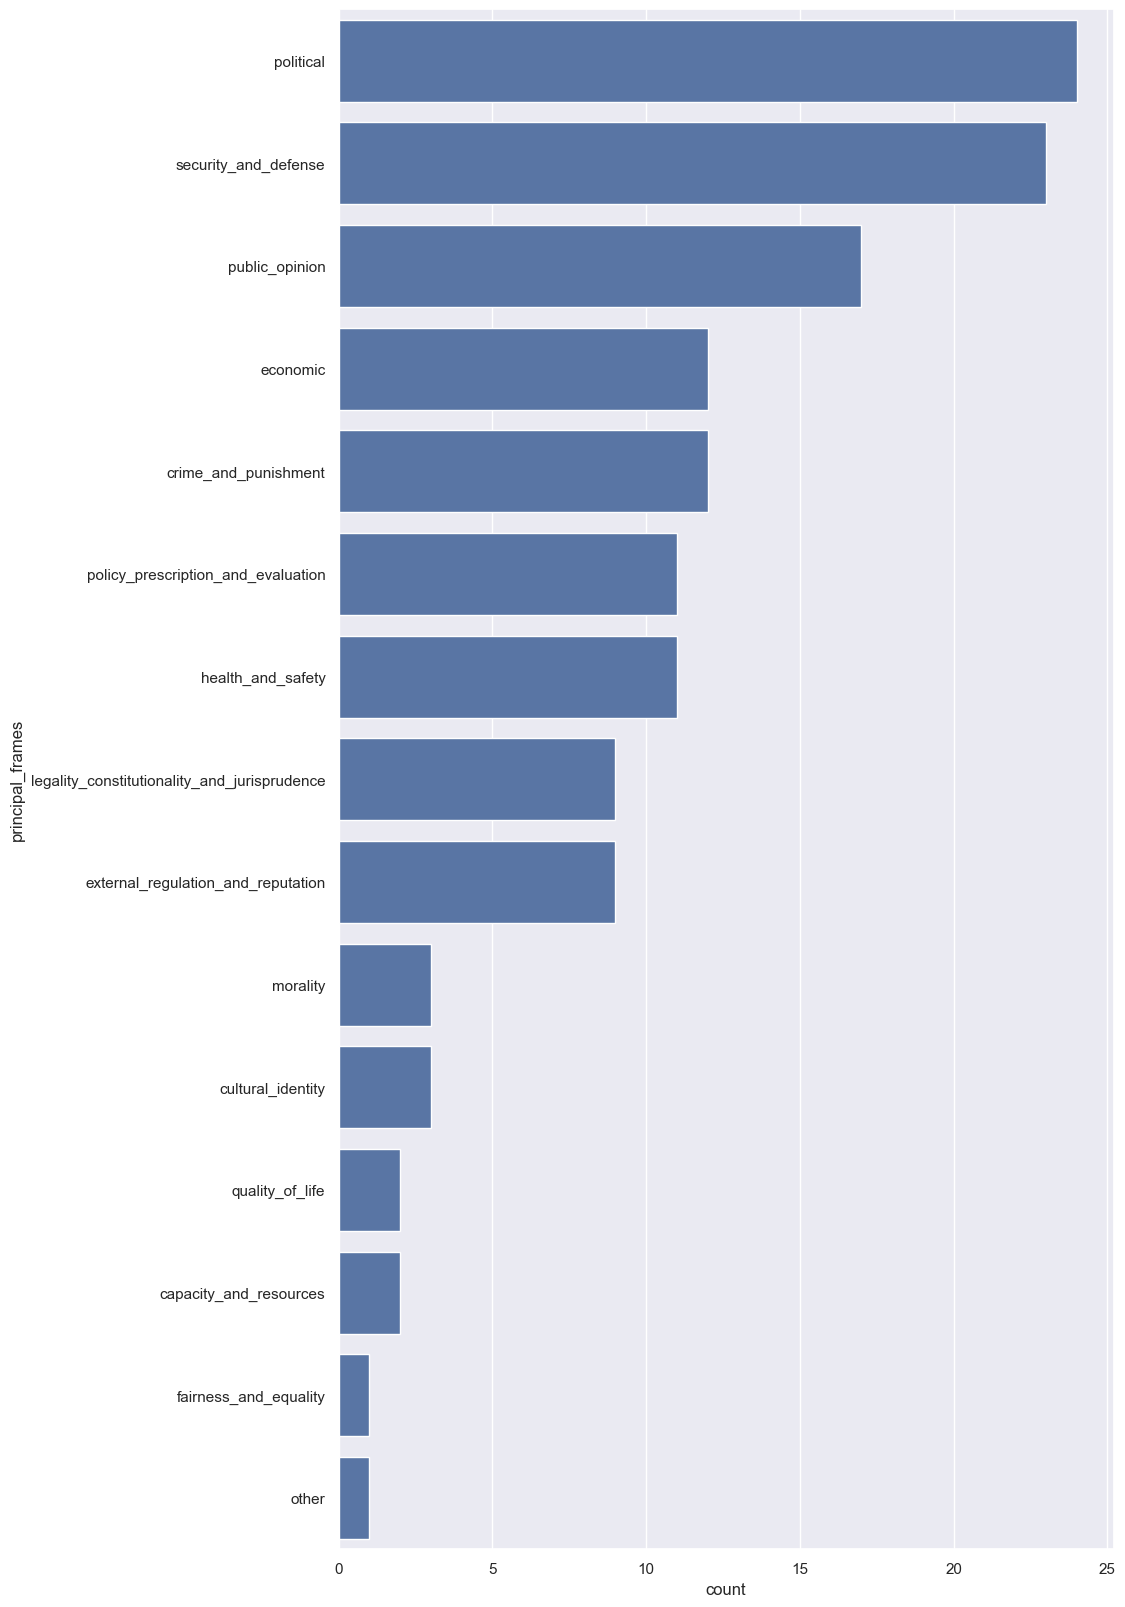

In [74]:

plt.figure(figsize=(10, 20))
sns.countplot(data=df, y="principal_frames", order=order)
plt.show()